# Assignment 2 — Momentum Signals & Cross-Section of Returns
S&P 500 constituents, 2010-01 through 2024-12.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as sp_stats
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

df = pd.read_excel('SP500Raw.xlsx')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['permno','date']).reset_index(drop=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique PERMNOs: {df['permno'].nunique()}, Unique dates: {df['date'].nunique()}")
df.head(10)

Shape: (90525, 6)
Date range: 2010-01-29 to 2024-12-31
Unique PERMNOs: 795, Unique dates: 180


,permno,date,price,shrout,prc,mcap
0,10104,2010-01-29,23.0600,5011220,-0.057888,1.155587e+08
1,10104,2010-02-26,24.6500,5015000,0.068951,1.236198e+08
2,10104,2010-03-31,25.7100,5019091,0.043002,1.290408e+08
3,10104,2010-04-30,25.8675,5029523,0.008071,1.301012e+08
4,10104,2010-05-28,22.5700,5026000,-0.127477,1.134368e+08
5,10104,2010-06-30,21.4600,5026000,-0.049180,1.078580e+08
6,10104,2010-07-30,23.6400,5026000,0.103914,1.188146e+08
7,10104,2010-08-31,21.8450,5025000,-0.075931,1.097711e+08
8,10104,2010-09-30,26.8500,5027114,0.229114,1.349780e+08
9,10104,2010-10-29,29.3800,5027114,0.096089,1.476966e+08


---
## Question 1
**Why does the dataset use PERMNO and not TICKERS, which is how stocks are identified on the major exchanges in the US?**

**Answer:** PERMNO is a permanent security identifier assigned by CRSP that stays constant for a given security over its entire life. Tickers, by contrast, can change over time — companies rebrand, merge, or get acquired, and their tickers change accordingly. More importantly, tickers are recycled: after a company delists, its ticker can be reassigned to a completely different company (e.g., "META" once belonged to a different firm before Facebook adopted it). Over a 15-year sample with hundreds of index changes, using tickers would create ambiguity about which company is being referenced. PERMNO eliminates this problem entirely.

---
## Question 2
**For many of the Companies, the one month percent change in price is not always equal to the PRC column.**

**a. Is this a data error or is this correct? Explain.**

**b. Why for some companies, the columns are always equal? Why?**

**Note: save this variable as Price_Ret(T1).**

In [2]:
# Calculate Price_Ret_T1 = one-month percent change in the price column
df['Price_Ret_T1'] = df.groupby('permno')['price'].pct_change()

# Compare with prc
mask = df['Price_Ret_T1'].notna() & df['prc'].notna()
diff = (df.loc[mask, 'Price_Ret_T1'] - df.loc[mask, 'prc']).abs()

print(f"Total observations with both available: {mask.sum()}")
print(f"Observations where |Price_Ret_T1 - prc| > 0.0001: {(diff > 0.0001).sum()}  ({(diff>0.0001).mean()*100:.1f}%)")
print(f"Observations where they are ≈ equal:               {(diff <= 0.0001).sum()}  ({(diff<=0.0001).mean()*100:.1f}%)")

Total observations with both available: 89722
Observations where |Price_Ret_T1 - prc| > 0.0001: 24123  (26.9%)
Observations where they are ≈ equal:               65599  (73.1%)


In [27]:
# How many companies are ALWAYS equal?
def always_equal(g):
    m = g['Price_Ret_T1'].notna() & g['prc'].notna()
    if m.sum() == 0: return False
    return (g.loc[m, 'Price_Ret_T1'] - g.loc[m, 'prc']).abs().max() < 0.0001

always_eq = df.groupby('permno').apply(always_equal)
print(f"Companies where Price_Ret_T1 ≡ prc always: {always_eq.sum()} / {len(always_eq)}")
print(f"Companies where they sometimes differ:      {(~always_eq).sum()}")

# Show an example where they differ
ex = df[df['permno']==10104][['permno','date','price','prc','Price_Ret_T1']].head(13).copy()
ex['difference'] = (ex['Price_Ret_T1'] - ex['prc']).round(6)
print("\nExample — PERMNO 10104 (a dividend-paying stock):")
display(ex)

Companies where Price_Ret_T1 ≡ prc always: 131 / 795
Companies where they sometimes differ:      664

Example — PERMNO 10104 (a dividend-paying stock):


,permno,date,price,prc,Price_Ret_T1,difference
0,10104,2010-01-29,23.0600,-0.057888,NaN,NaN
1,10104,2010-02-26,24.6500,0.068951,0.068951,-0.000000
2,10104,2010-03-31,25.7100,0.043002,0.043002,0.000000
3,10104,2010-04-30,25.8675,0.008071,0.006126,-0.001945
4,10104,2010-05-28,22.5700,-0.127477,-0.127477,0.000000
5,10104,2010-06-30,21.4600,-0.049180,-0.049180,-0.000000
6,10104,2010-07-30,23.6400,0.103914,0.101584,-0.002330
7,10104,2010-08-31,21.8450,-0.075931,-0.075931,0.000000
8,10104,2010-09-30,26.8500,0.229114,0.229114,0.000000
9,10104,2010-10-29,29.3800,0.096089,0.094227,-0.001862


**Answer 2a:** This is NOT a data error. The `prc` column represents the **total return** of the security (i.e., the return including dividends, distributions, and the effect of splits), while the percent change in `price` is only the **price return** (capital appreciation). When a stock pays a dividend, the price drops by approximately the dividend amount on the ex-date, so the price return is lower than the total return for that month. The difference between the two is attributable to these distributions.

**Answer 2b:** For companies where the two are always equal, those are companies that **never paid a dividend** (and had no other distributions that would create a difference) during the sample period. These tend to be growth stocks that reinvest all earnings rather than distributing them to shareholders.

---
## Question 3
**For each date count the number of companies that exist. Why is it not always 500? Is this a mistake? Explain.**

Min: 500,  Max: 506,  Mean: 502.9
Dates with exactly 500: 51 / 180
Dates with > 500:       129
Dates with < 500:       0


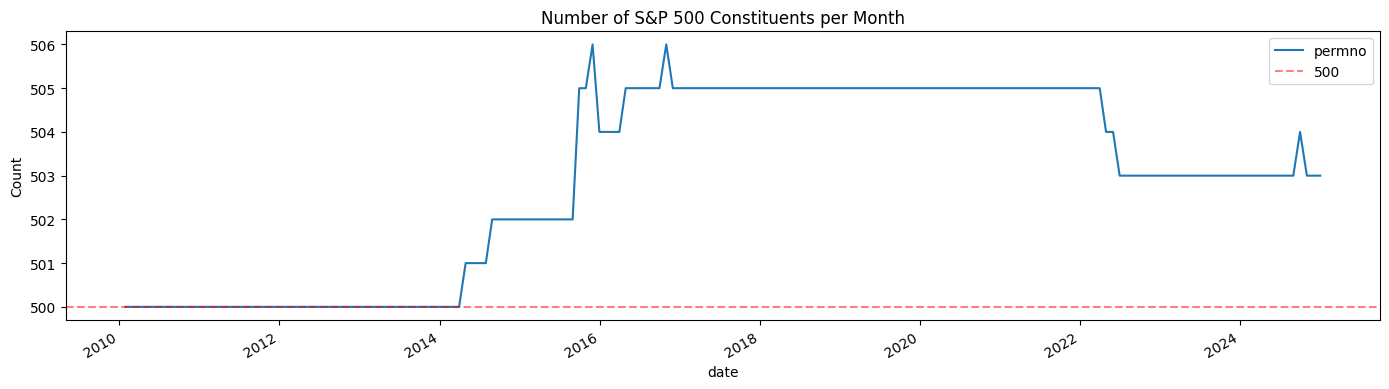


First 10 dates:


date
2010-01-29    500
2010-02-26    500
2010-03-31    500
2010-04-30    500
2010-05-28    500
2010-06-30    500
2010-07-30    500
2010-08-31    500
2010-09-30    500
2010-10-29    500
Name: permno, dtype: int64

Last 10 dates:


date
2024-03-28    503
2024-04-30    503
2024-05-31    503
2024-06-28    503
2024-07-31    503
2024-08-30    503
2024-09-30    504
2024-10-31    503
2024-11-29    503
2024-12-31    503
Name: permno, dtype: int64

In [4]:
counts = df.groupby('date')['permno'].nunique()
print(f"Min: {counts.min()},  Max: {counts.max()},  Mean: {counts.mean():.1f}")
print(f"Dates with exactly 500: {(counts==500).sum()} / {len(counts)}")
print(f"Dates with > 500:       {(counts>500).sum()}")
print(f"Dates with < 500:       {(counts<500).sum()}")

fig, ax = plt.subplots(figsize=(14, 4))
counts.plot(ax=ax)
ax.axhline(500, color='red', ls='--', alpha=0.5, label='500')
ax.set_title('Number of S&P 500 Constituents per Month')
ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()

print("\nFirst 10 dates:")
display(counts.head(10))
print("Last 10 dates:")
display(counts.tail(10))

**Answer:** This is NOT a mistake. The S&P 500 index does not always have exactly 500 securities because:
1. Some companies have **multiple share classes** (e.g., Alphabet has GOOGL and GOOG, News Corp has NWSA and NWS), and both may be included as separate PERMNOs, pushing the count above 500.
2. During index **rebalancing**, additions and deletions may not occur on the exact same day, causing temporary discrepancies.
3. **Mergers, spin-offs, and delistings** can temporarily reduce the count before a replacement is added by the index committee.

---
## Question 4
**How many of the companies are present over the entire sample? How many unique companies are in the sample?**

Total months in sample:                  180
Companies present ALL 180 months:       285
Total unique companies (PERMNOs):         795

Distribution of months present per company:


count    795.000000
mean     113.867925
std       61.862254
min        1.000000
25%       60.000000
50%      114.000000
75%      180.000000
max      180.000000
Name: date, dtype: float64

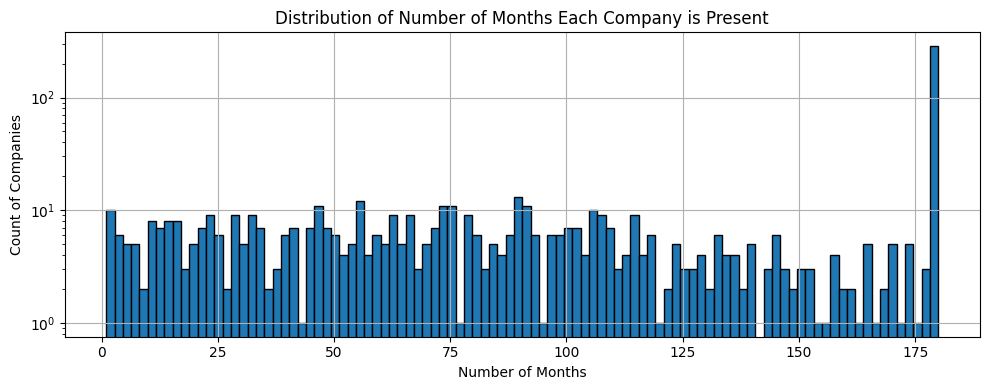

In [7]:
total_dates = df['date'].nunique()
months_per_company = df.groupby('permno')['date'].nunique()
present_all = (months_per_company == total_dates).sum()

print(f"Total months in sample:                  {total_dates}")
print(f"Companies present ALL {total_dates} months:       {present_all}")
print(f"Total unique companies (PERMNOs):         {df['permno'].nunique()}")

print(f"\nDistribution of months present per company:")
display(months_per_company.describe())

fig, ax = plt.subplots(figsize=(10, 4))
months_per_company.hist(bins=100, ax=ax, edgecolor='black')
ax.set_title('Distribution of Number of Months Each Company is Present')
ax.set_xlabel('Number of Months'); ax.set_ylabel('Count of Companies')
plt.yscale("log")
plt.tight_layout(); plt.show()

---
## Question 5
**Plot the time series of the max, 95th, 75th, median, 25th, 5th, and min market cap for each month.**

**a. Calculate the above for stocks the month prior to their leaving the sample.**

**b. Repeat for companies on the month they enter the sample.**

In [8]:
pct_labels = ['min','p5','p25','median','p75','p95','max']
pct_values = [0,5,25,50,75,95,100]

def calc_percentiles(group, col='mcap'):
    v = group[col].dropna()
    if len(v) == 0: return pd.Series([np.nan]*7, index=pct_labels)
    return pd.Series(np.percentile(v, pct_values), index=pct_labels)

def plot_percentiles(pct_df, title, ylabel='', log_scale=False):
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ['red','orange','green','blue','green','orange','red']
    styles = ['--','--','-','-','-','--','--']
    for col_name, c, s in zip(pct_labels, colors, styles):
        ax.plot(pct_df.index, pct_df[col_name], label=col_name, color=c, linestyle=s)
    if log_scale: ax.set_yscale('log')
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.legend(ncol=7, loc='upper left')
    plt.tight_layout(); plt.show()

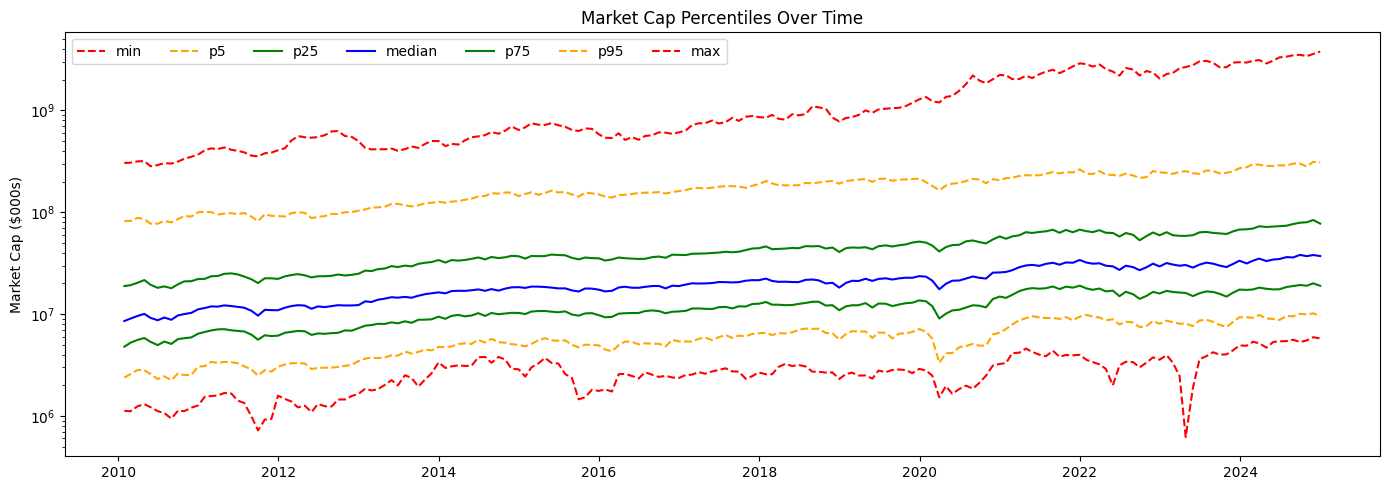

Median of each percentile time-series (Market Cap, $000s):


min       2.623974e+06
p5        5.545501e+06
p25       1.111962e+07
median    2.000460e+07
p75       4.032531e+07
p95       1.741709e+08
max       7.742933e+08
dtype: float64

In [28]:
# 5 — Main: Market cap percentiles over time
mcap_pcts = df.groupby('date').apply(calc_percentiles)
plot_percentiles(mcap_pcts, 'Market Cap Percentiles Over Time', 'Market Cap ($000s)', log_scale=True)

print("Median of each percentile time-series (Market Cap, $000s):")
display(mcap_pcts.median())

Total company-exit observations: 301


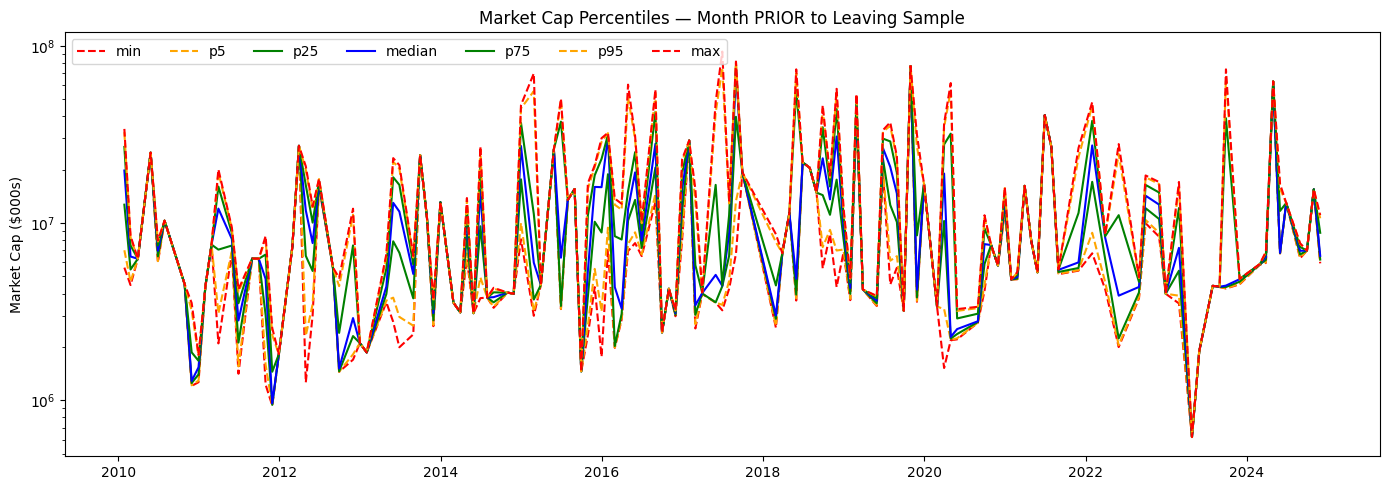

Median of each percentile (leavers):


min       4.504323e+06
p5        4.827668e+06
p25       6.225747e+06
median    6.527089e+06
p75       8.787414e+06
p95       1.113388e+07
max       1.140592e+07
dtype: float64

In [10]:
# 5a — Leavers: month prior to leaving
dates_sorted = sorted(df['date'].unique())
companies_by_date = df.groupby('date')['permno'].apply(set).to_dict()

leavers = []
for i in range(len(dates_sorted)-1):
    t, t1 = dates_sorted[i], dates_sorted[i+1]
    leaving = companies_by_date[t] - companies_by_date[t1]
    if leaving:
        leavers.append(df[(df['date']==t) & (df['permno'].isin(leaving))])
leavers_df = pd.concat(leavers)
print(f"Total company-exit observations: {len(leavers_df)}")

lp = leavers_df.groupby('date').apply(calc_percentiles).dropna(how='all')
plot_percentiles(lp, 'Market Cap Percentiles — Month PRIOR to Leaving Sample', 'Market Cap ($000s)', True)
print("Median of each percentile (leavers):")
display(lp.median())

Total company-entry observations: 804


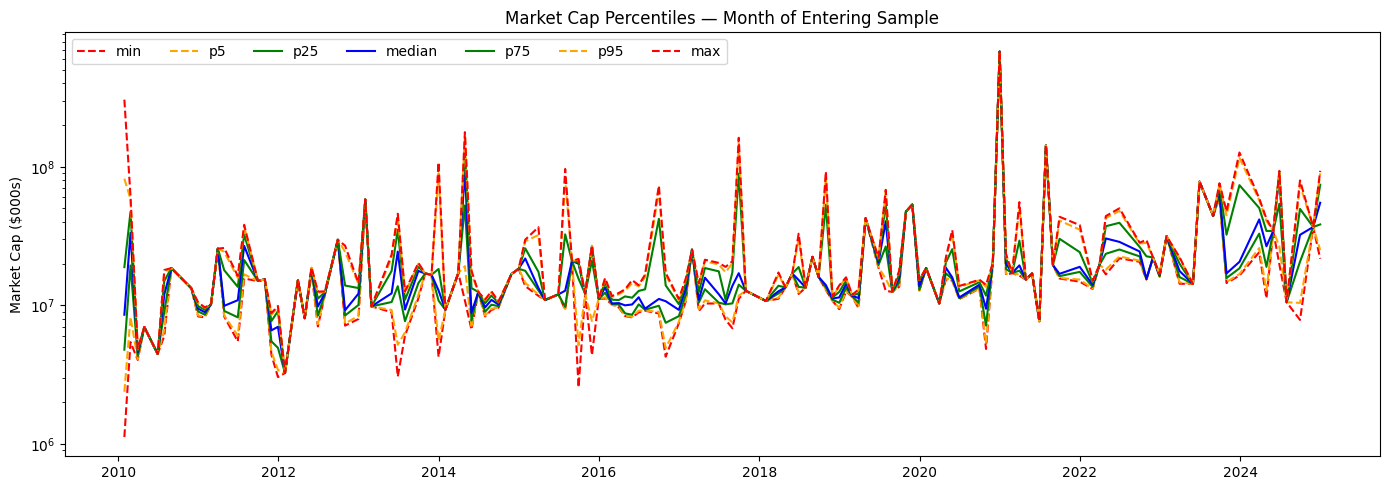

Median of each percentile (enterers):


min       1.248576e+07
p5        1.273659e+07
p25       1.359730e+07
median    1.425316e+07
p75       1.695235e+07
p95       1.709851e+07
max       1.773424e+07
dtype: float64

In [11]:
# 5b — Enterers: month of entering
enterers = [df[df['date']==dates_sorted[0]]]  # everyone on first date enters
for i in range(1, len(dates_sorted)):
    entering = companies_by_date[dates_sorted[i]] - companies_by_date[dates_sorted[i-1]]
    if entering:
        enterers.append(df[(df['date']==dates_sorted[i]) & (df['permno'].isin(entering))])
enterers_df = pd.concat(enterers)
print(f"Total company-entry observations: {len(enterers_df)}")

ep = enterers_df.groupby('date').apply(calc_percentiles).dropna(how='all')
plot_percentiles(ep, 'Market Cap Percentiles — Month of Entering Sample', 'Market Cap ($000s)', True)
print("Median of each percentile (enterers):")
display(ep.median())

---
## Trailing & Forward Return Calculations

All returns are **geometric** (compounded).

Computed variables:
- (i) `PRC_Ret_T12` — trailing 12M total return (prc-based)
- (ii) `Prices_Ret_T12` — trailing 12M price return
- (iii) `PRC_Ret_T12M1` — trailing 12M excluding most recent month (prc-based)
- (iv) `Prices_Ret_T12M1` — same, price-based
- (v) `PRC_Ret_T12_1M` / `Prices_Ret_T12_1M` — the single month return from exactly 12 months ago
- (vi) `Vol_Prices_Ret_T12M1` / `SR_Prices_Ret_T12M1` — vol and Sharpe ratio of monthly returns in T12M1 window
- Forward: `PRC_Ret_F1M`, `PRC_Ret_F3M`, `PRC_Ret_F6M`

In [12]:
df = df.sort_values(['permno','date']).reset_index(drop=True)
df['ym'] = df['date'].dt.to_period('M')

# Pre-allocate new columns
new_cols = ['PRC_Ret_T12','Prices_Ret_T12','PRC_Ret_T12M1','Prices_Ret_T12M1',
            'PRC_Ret_T12_1M','Prices_Ret_T12_1M','Vol_Prices_Ret_T12M1','SR_Prices_Ret_T12M1',
            'PRC_Ret_F1M','PRC_Ret_F3M','PRC_Ret_F6M']
for c in new_cols:
    df[c] = np.nan

print("Computing trailing and forward returns per company...")
for permno, idx in df.groupby('permno').groups.items():
    g = df.loc[idx]
    gi = g.index.values
    n = len(g)
    prc_ret = g['prc'].values
    price_ret = g['Price_Ret_T1'].values
    dates = g['ym'].values
    
    # --- Trailing returns ---
    for k in range(12, n):
        if (dates[k] - dates[k-12]).n != 12:
            continue
        
        # 12 months of returns: indices k-11 through k
        r12_prc = prc_ret[k-11:k+1]
        r12_pri = price_ret[k-11:k+1]
        # 11 months (exclude most recent): indices k-11 through k-1
        r11_prc = prc_ret[k-11:k]
        r11_pri = price_ret[k-11:k]
        
        # (i) PRC_Ret(T12)
        if not np.any(np.isnan(r12_prc)):
            df.at[gi[k], 'PRC_Ret_T12'] = np.prod(1 + r12_prc) - 1
        # (ii) Prices_Ret(T12)
        if not np.any(np.isnan(r12_pri)):
            df.at[gi[k], 'Prices_Ret_T12'] = np.prod(1 + r12_pri) - 1
        # (iii) PRC_Ret(T12M1)
        if not np.any(np.isnan(r11_prc)):
            df.at[gi[k], 'PRC_Ret_T12M1'] = np.prod(1 + r11_prc) - 1
        # (iv) Prices_Ret(T12M1)
        if not np.any(np.isnan(r11_pri)):
            val = np.prod(1 + r11_pri) - 1
            df.at[gi[k], 'Prices_Ret_T12M1'] = val
            # (vi) Vol and SR
            vol = np.std(r11_pri, ddof=1)
            df.at[gi[k], 'Vol_Prices_Ret_T12M1'] = vol
            if vol > 0:
                df.at[gi[k], 'SR_Prices_Ret_T12M1'] = val / vol
        # (v) Return from exactly 12 months ago = the return at index k-11
        if not np.isnan(prc_ret[k-11]):
            df.at[gi[k], 'PRC_Ret_T12_1M'] = prc_ret[k-11]
        if not np.isnan(price_ret[k-11]):
            df.at[gi[k], 'Prices_Ret_T12_1M'] = price_ret[k-11]
    
    # --- Forward returns ---
    for k in range(n):
        # F1M
        if k+1 < n and (dates[k+1]-dates[k]).n == 1 and not np.isnan(prc_ret[k+1]):
            df.at[gi[k], 'PRC_Ret_F1M'] = prc_ret[k+1]
        # F3M
        if k+3 < n and (dates[k+3]-dates[k]).n == 3:
            r = prc_ret[k+1:k+4]
            if not np.any(np.isnan(r)):
                df.at[gi[k], 'PRC_Ret_F3M'] = np.prod(1+r) - 1
        # F6M
        if k+6 < n and (dates[k+6]-dates[k]).n == 6:
            r = prc_ret[k+1:k+7]
            if not np.any(np.isnan(r)):
                df.at[gi[k], 'PRC_Ret_F6M'] = np.prod(1+r) - 1

print("Done. Non-null counts:")
for c in new_cols:
    print(f"  {c:<25s}: {df[c].notna().sum():>6d}")

Computing trailing and forward returns per company...
Done. Non-null counts:
  PRC_Ret_T12              :  81100
  Prices_Ret_T12           :  81100
  PRC_Ret_T12M1            :  81107
  Prices_Ret_T12M1         :  81107
  PRC_Ret_T12_1M           :  81107
  Prices_Ret_T12_1M        :  81107
  Vol_Prices_Ret_T12M1     :  81107
  SR_Prices_Ret_T12M1      :  81107
  PRC_Ret_F1M              :  89713
  PRC_Ret_F3M              :  88122
  PRC_Ret_F6M              :  85757


---
## Question 6
**For all variables, produce one time series graph for each variable showing the Percentile Sets. For each, also calculate the median value of the time series of each percentile.**

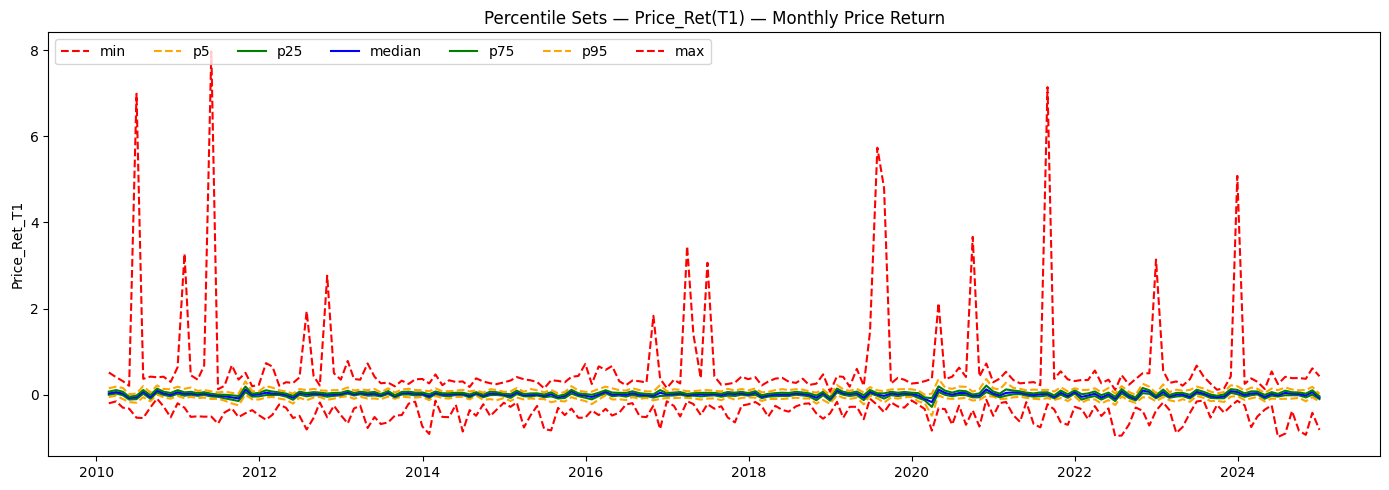

Median of each percentile for Price_Ret(T1) — Monthly Price Return:


,Percentile,Median Value
0,min,-0.376185
1,p5,-0.089134
2,p25,-0.022078
3,median,0.010877
4,p75,0.046525
5,p95,0.109271
6,max,0.361648


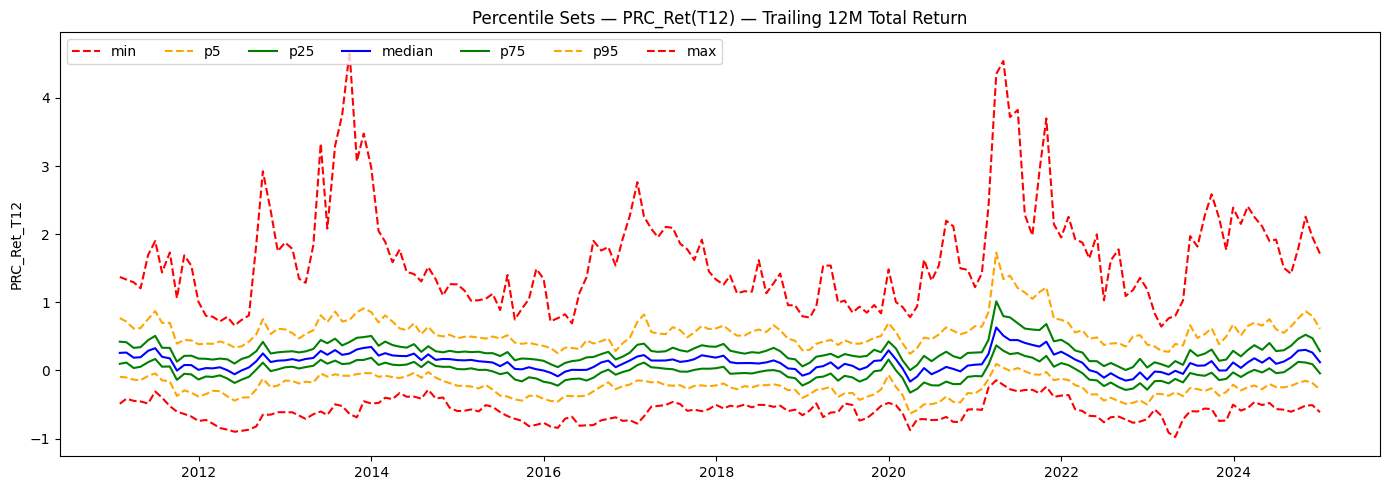

Median of each percentile for PRC_Ret(T12) — Trailing 12M Total Return:


,Percentile,Median Value
0,min,-0.595623
1,p5,-0.245591
2,p25,-0.021947
3,median,0.121472
4,p75,0.270031
5,p95,0.533082
6,max,1.502081


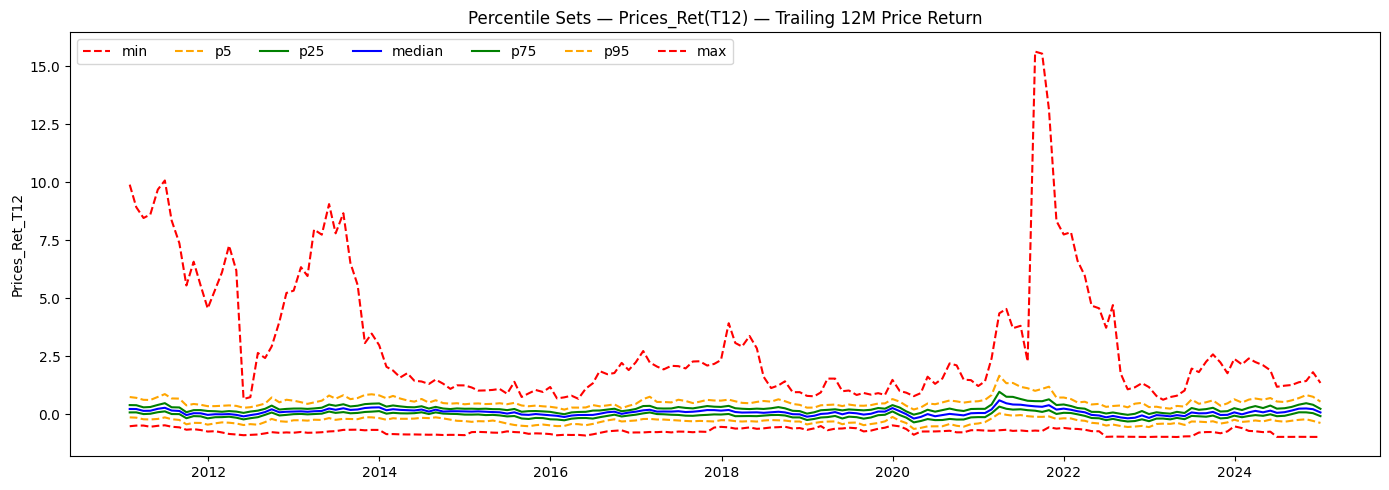

Median of each percentile for Prices_Ret(T12) — Trailing 12M Price Return:


,Percentile,Median Value
0,min,-0.745554
1,p5,-0.300539
2,p25,-0.055606
3,median,0.089438
4,p75,0.241028
5,p95,0.513025
6,max,1.902210


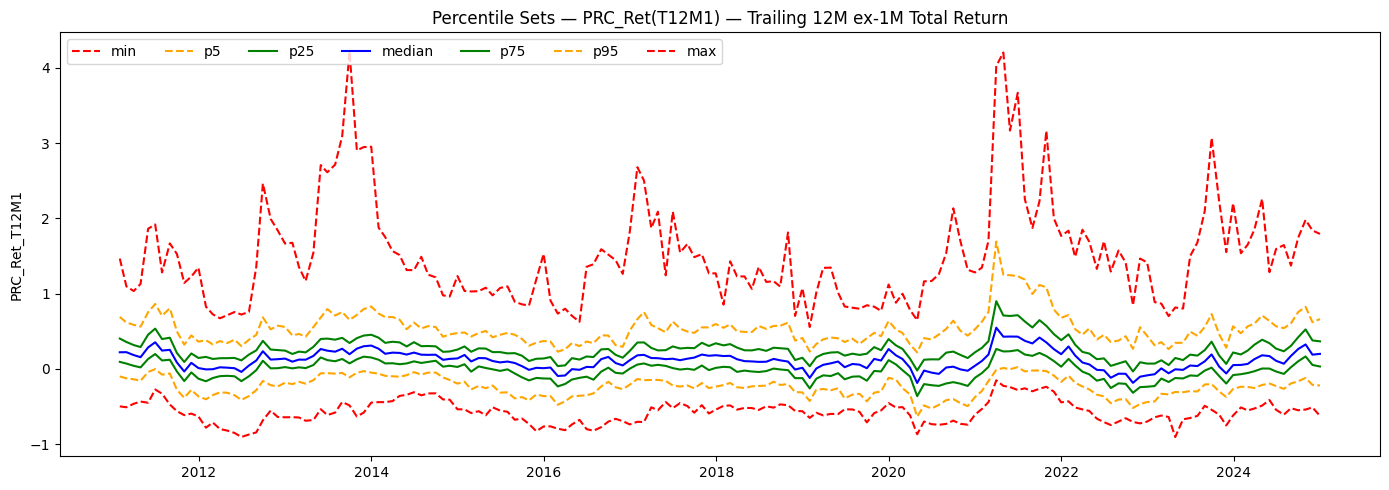

Median of each percentile for PRC_Ret(T12M1) — Trailing 12M ex-1M Total Return:


,Percentile,Median Value
0,min,-0.566836
1,p5,-0.234765
2,p25,-0.017903
3,median,0.111881
4,p75,0.245770
5,p95,0.501145
6,max,1.353712


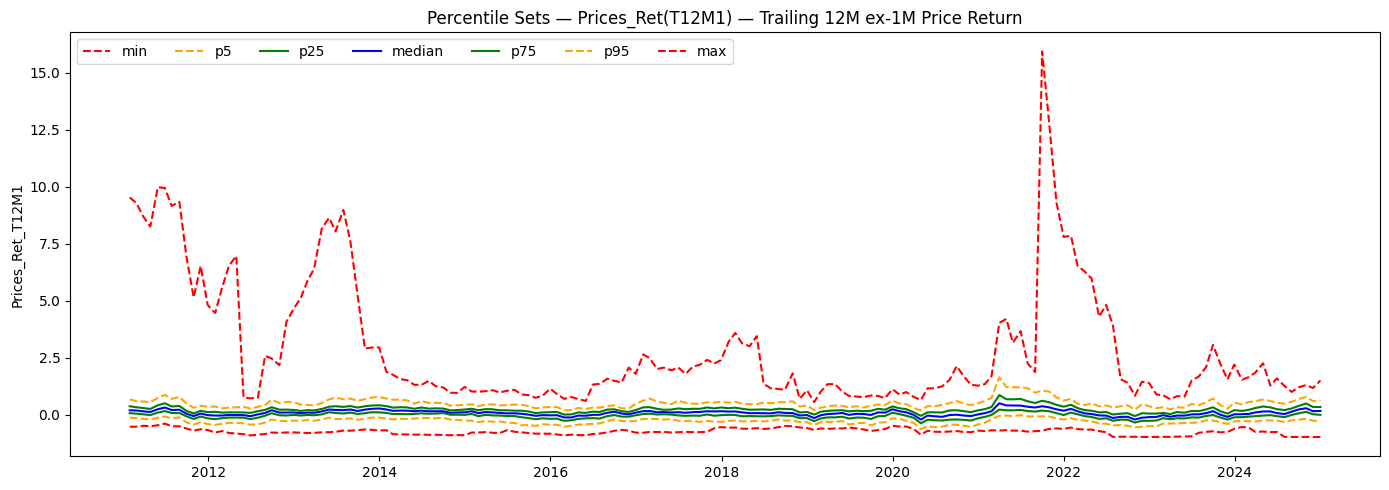

Median of each percentile for Prices_Ret(T12M1) — Trailing 12M ex-1M Price Return:


,Percentile,Median Value
0,min,-0.748977
1,p5,-0.276830
2,p25,-0.049776
3,median,0.084931
4,p75,0.221707
5,p95,0.481597
6,max,1.584648


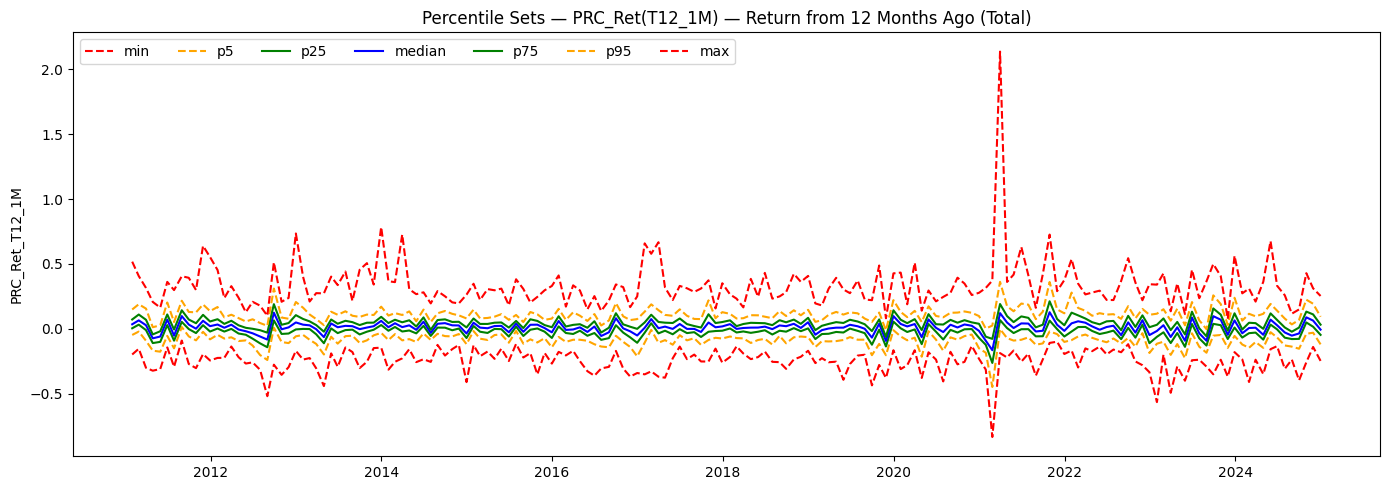

Median of each percentile for PRC_Ret(T12_1M) — Return from 12 Months Ago (Total):


,Percentile,Median Value
0,min,-0.236615
1,p5,-0.085092
2,p25,-0.021475
3,median,0.012519
4,p75,0.047873
5,p95,0.110316
6,max,0.308980


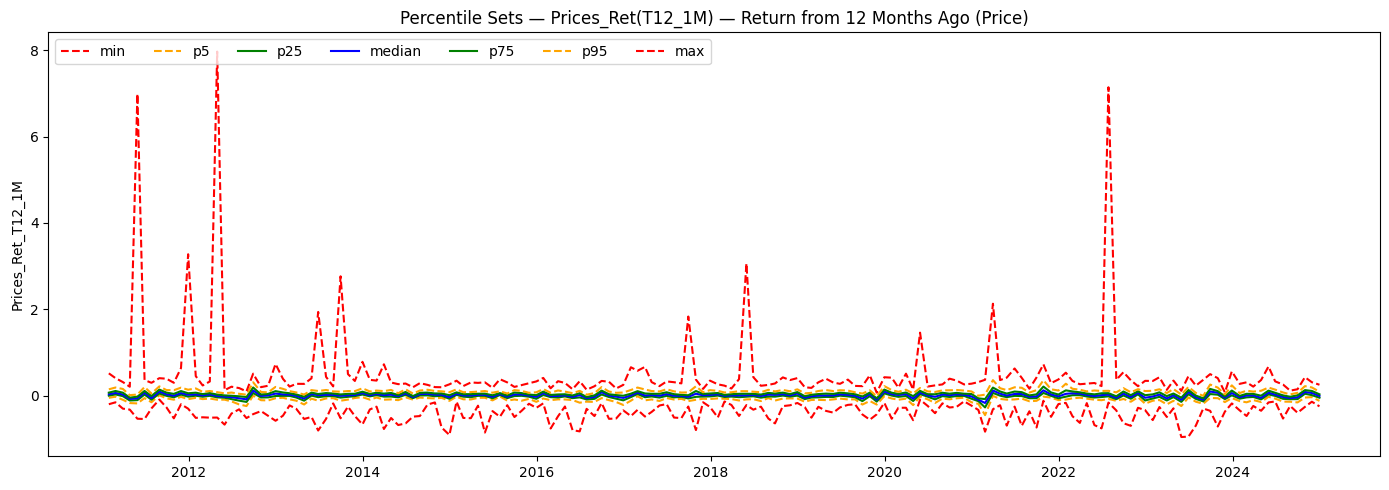

Median of each percentile for Prices_Ret(T12_1M) — Return from 12 Months Ago (Price):


,Percentile,Median Value
0,min,-0.350809
1,p5,-0.086995
2,p25,-0.022527
3,median,0.010915
4,p75,0.045061
5,p95,0.108497
6,max,0.315211


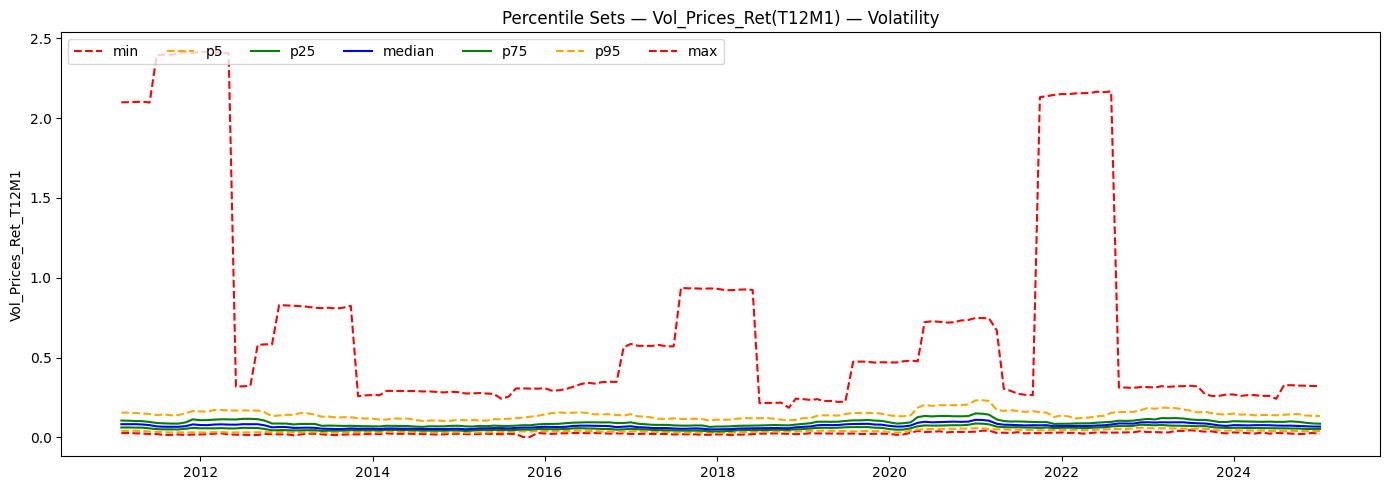

Median of each percentile for Vol_Prices_Ret(T12M1) — Volatility:


,Percentile,Median Value
0,min,0.023271
1,p5,0.038241
2,p25,0.055218
3,median,0.071222
4,p75,0.091746
5,p95,0.140415
6,max,0.344251


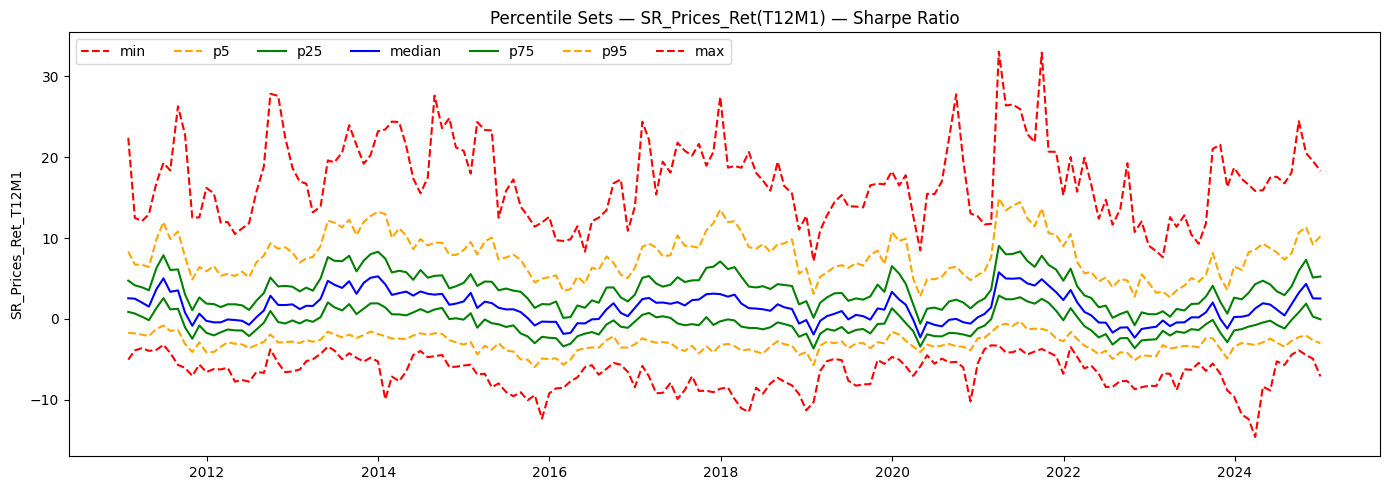

Median of each percentile for SR_Prices_Ret(T12M1) — Sharpe Ratio:


,Percentile,Median Value
0,min,-6.420955
1,p5,-3.051784
2,p25,-0.700017
3,median,1.315647
4,p75,3.821433
5,p95,7.778726
6,max,16.787602


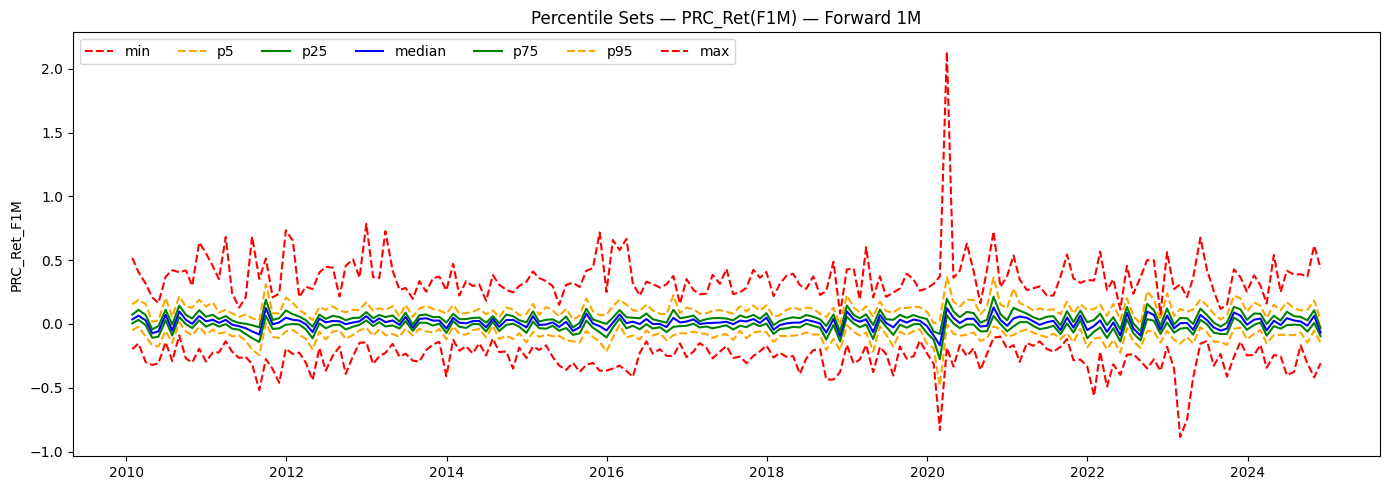

Median of each percentile for PRC_Ret(F1M) — Forward 1M:


,Percentile,Median Value
0,min,-0.252192
1,p5,-0.086774
2,p25,-0.021301
3,median,0.012537
4,p75,0.048324
5,p95,0.110504
6,max,0.348629


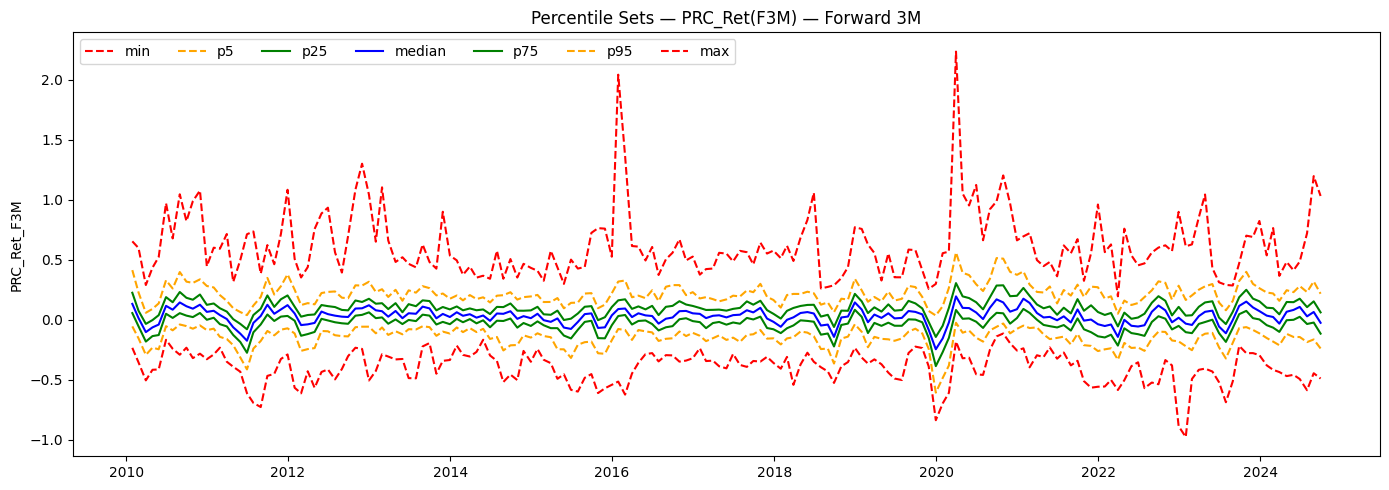

Median of each percentile for PRC_Ret(F3M) — Forward 3M:


,Percentile,Median Value
0,min,-0.374626
1,p5,-0.140920
2,p25,-0.027624
3,median,0.036315
4,p75,0.102055
5,p95,0.217004
6,max,0.560159


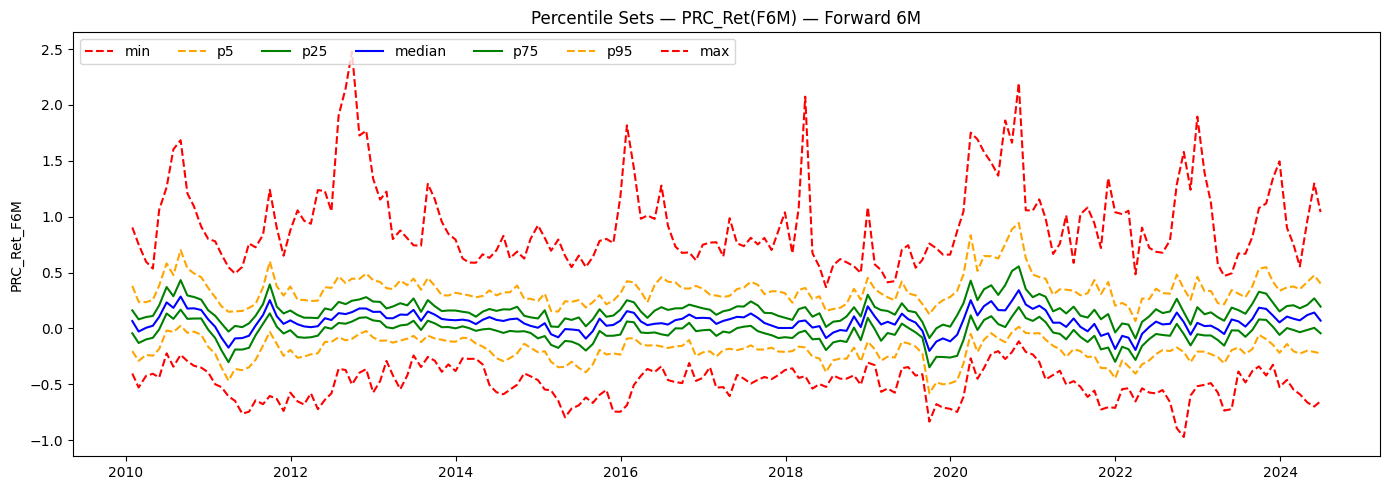

Median of each percentile for PRC_Ret(F6M) — Forward 6M:


,Percentile,Median Value
0,min,-0.490498
1,p5,-0.193906
2,p25,-0.034984
3,median,0.067739
4,p75,0.162514
5,p95,0.335997
6,max,0.810623


In [13]:
vars_to_plot = [
    ('Price_Ret_T1',        'Price_Ret(T1) — Monthly Price Return'),
    ('PRC_Ret_T12',         'PRC_Ret(T12) — Trailing 12M Total Return'),
    ('Prices_Ret_T12',      'Prices_Ret(T12) — Trailing 12M Price Return'),
    ('PRC_Ret_T12M1',       'PRC_Ret(T12M1) — Trailing 12M ex-1M Total Return'),
    ('Prices_Ret_T12M1',    'Prices_Ret(T12M1) — Trailing 12M ex-1M Price Return'),
    ('PRC_Ret_T12_1M',      'PRC_Ret(T12_1M) — Return from 12 Months Ago (Total)'),
    ('Prices_Ret_T12_1M',   'Prices_Ret(T12_1M) — Return from 12 Months Ago (Price)'),
    ('Vol_Prices_Ret_T12M1','Vol_Prices_Ret(T12M1) — Volatility'),
    ('SR_Prices_Ret_T12M1', 'SR_Prices_Ret(T12M1) — Sharpe Ratio'),
    ('PRC_Ret_F1M',         'PRC_Ret(F1M) — Forward 1M'),
    ('PRC_Ret_F3M',         'PRC_Ret(F3M) — Forward 3M'),
    ('PRC_Ret_F6M',         'PRC_Ret(F6M) — Forward 6M'),
]

for var_col, var_label in vars_to_plot:
    pcts = df.groupby('date').apply(lambda g, vc=var_col: calc_percentiles(g, col=vc)).dropna(how='all')
    plot_percentiles(pcts, f'Percentile Sets — {var_label}', var_col)
    med = pcts.median()
    print(f"Median of each percentile for {var_label}:")
    display(pd.DataFrame({'Percentile': pct_labels, 'Median Value': [f'{med[p]:.6f}' for p in pct_labels]}))
    print()

---
## Question 7: Fama-MacBeth Cross-Sectional Regressions

### 7(a)
**For the period November 2019 where the dependent variable is the one month forward return (Oct 31 to Nov 30 2019) and the independent variable is PRC_Ret(T12M1). Report and interpret the coefficient.**

In [14]:
oct2019 = df[df['date'].dt.to_period('M') == '2019-10'].dropna(subset=['PRC_Ret_F1M','PRC_Ret_T12M1'])
X = sm.add_constant(oct2019['PRC_Ret_T12M1'])
model = sm.OLS(oct2019['PRC_Ret_F1M'], X).fit()

print(f"Cross-sectional regression for Nov 2019 forward return (as of Oct 2019 EOM)")
print(f"N = {model.nobs:.0f}")
print(model.summary().tables[1])

Cross-sectional regression for Nov 2019 forward return (as of Oct 2019 EOM)
N = 482
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0415      0.003     13.018      0.000       0.035       0.048
PRC_Ret_T12M1    -0.0639      0.012     -5.275      0.000      -0.088      -0.040


**Interpretation:** The coefficient on PRC_Ret(T12M1) represents the expected additional forward one-month return per unit of trailing 12-month (ex-last-month) momentum. A positive coefficient means past winners continue to outperform (momentum); negative means reversal.

### 7(b)
**Run the same cross-sectional regression for the entire sample. Plot the time series of coefficients. Calculate statistical significance.**

In [15]:
def fama_macbeth(df, dep_var, indep_vars, weight_col=None):
    """Run Fama-MacBeth cross-sectional regressions."""
    all_vars = [dep_var] + indep_vars
    results = []
    for d, sub in df.groupby('date'):
        sub = sub.dropna(subset=all_vars)
        if weight_col is not None:
            sub = sub.dropna(subset=[weight_col])
            sub = sub[sub[weight_col] > 0]
        if len(sub) < len(indep_vars) + 5:
            continue
        X = sm.add_constant(sub[indep_vars])
        y = sub[dep_var]
        try:
            if weight_col is not None:
                m = sm.WLS(y, X, weights=sub[weight_col]).fit()
            else:
                m = sm.OLS(y, X).fit()
            row = {'date': d, 'n_obs': int(m.nobs), 'const': m.params['const']}
            for v in indep_vars:
                row[v] = m.params[v]
            results.append(row)
        except:
            continue
    return pd.DataFrame(results).set_index('date')

def fmb_summary(res_df, indep_vars):
    """Compute Fama-MacBeth t-stats (time-series mean / SE)."""
    rows = []
    for v in ['const'] + indep_vars:
        c = res_df[v].dropna()
        m = c.mean(); s = c.std(); se = s / np.sqrt(len(c))
        t = m / se if se > 0 else np.nan
        rows.append({'Variable': v, 'Mean Coef': m, 'Std': s, 'SE': se, 't-stat': t, 'N periods': len(c)})
    return pd.DataFrame(rows)

In [16]:
fmb_7b = fama_macbeth(df, 'PRC_Ret_F1M', ['PRC_Ret_T12M1'])
s7b = fmb_summary(fmb_7b, ['PRC_Ret_T12M1'])
print("Fama-MacBeth: PRC_Ret(F1M) ~ PRC_Ret(T12M1) — Entire sample")
display(s7b)

Fama-MacBeth: PRC_Ret(F1M) ~ PRC_Ret(T12M1) — Entire sample


,Variable,Mean Coef,Std,SE,t-stat,N periods
0,const,0.009689,0.048206,0.003730,2.597362,167
1,PRC_Ret_T12M1,0.002614,0.066703,0.005162,0.506339,167


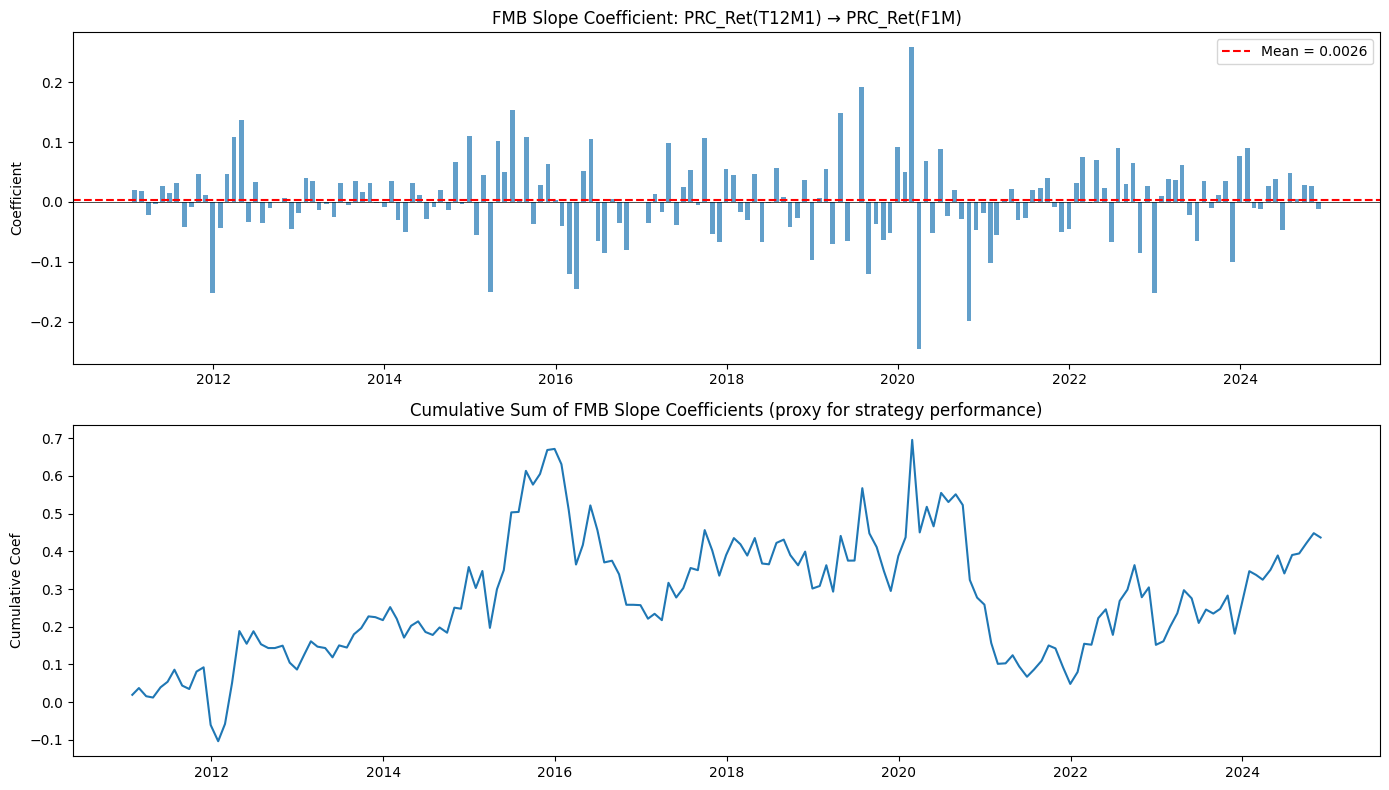

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(fmb_7b.index, fmb_7b['PRC_Ret_T12M1'], width=20, alpha=0.7)
axes[0].axhline(fmb_7b['PRC_Ret_T12M1'].mean(), color='red', ls='--',
                 label=f"Mean = {fmb_7b['PRC_Ret_T12M1'].mean():.4f}")
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('FMB Slope Coefficient: PRC_Ret(T12M1) → PRC_Ret(F1M)')
axes[0].set_ylabel('Coefficient'); axes[0].legend()

axes[1].plot(fmb_7b['PRC_Ret_T12M1'].cumsum())
axes[1].set_title('Cumulative Sum of FMB Slope Coefficients (proxy for strategy performance)')
axes[1].set_ylabel('Cumulative Coef')
plt.tight_layout(); plt.show()

### 7(c)
**Interpret your result, both economically and statistically. What conclusion about Momentum [-12, -1] as investment strategy? Explain to a layperson. Are results consistent across time?**

In [18]:
coefs = fmb_7b['PRC_Ret_T12M1']
print(f"Mean coefficient:  {coefs.mean():.6f}")
print(f"Median coefficient:{coefs.median():.6f}")
print(f"t-statistic:       {coefs.mean()/(coefs.std()/np.sqrt(len(coefs))):.3f}")
print(f"Hit rate:          {(coefs>0).mean()*100:.1f}%")
print(f"Number of months:  {len(coefs)}")

yearly = fmb_7b.copy()
yearly['year'] = pd.to_datetime(yearly.index).year
print("\nMean coefficient by year:")
display(yearly.groupby('year')['PRC_Ret_T12M1'].agg(['mean','std','count']).rename(
    columns={'mean':'Mean Coef','std':'Std','count':'N months'}))

Mean coefficient:  0.002614
Median coefficient:0.001375
t-statistic:       0.506
Hit rate:          52.1%
Number of months:  167

Mean coefficient by year:


,Mean Coef,Std,N months
year,,,
2011,-0.005017,0.052473,12
2012,0.012235,0.059351,12
2013,0.010908,0.022901,12
2014,0.011728,0.044875,12
2015,0.026079,0.082103,12
2016,-0.034500,0.071414,12
2017,0.011048,0.057730,12
2018,-0.007380,0.048464,12
2019,0.007169,0.095965,12


**Statistical interpretation:** The Fama-MacBeth t-statistic tests whether the average cross-sectional relationship between past 12M-1M returns and forward returns is significantly different from zero. |t| > 2 indicates significance at the 5% level.

**Economic interpretation:** The slope coefficient represents the expected additional return per unit of momentum. For example, a coefficient of 0.01 means a stock with 100% higher trailing momentum earns about 1% more next month. This is the classic Jegadeesh-Titman (1993) momentum effect.

**Time consistency:** Momentum is NOT consistent across time. It performs well during trending markets but suffers devastating "momentum crashes" during sharp market reversals — most notably the March 2009 recovery (past losers skyrocketed while past winners lagged) and potentially during the COVID recovery in 2020. The yearly breakdown highlights these episodes.

**For a layperson:** Stocks that have gone up a lot in the past year (excluding the last month) tend to continue going up next month, and stocks that have gone down tend to keep going down. This isn't guaranteed — sometimes the pattern reverses violently — but on average it has been a modestly profitable pattern. The challenge is that the bad months can be extremely bad.

### 7(d)
**Performance measures from Pedersen Ch.2: hit rates, drawdowns, max drawdown, slugging rate, Sortino ratio, etc.**

=== Performance Measures (treating FMB coefficients as strategy returns) ===
Hit Rate:              52.1%
Avg Gain (pos months): 0.049241
Avg Loss (neg months): -0.048094
Slugging Ratio:        1.02
Max Drawdown (cum):    -0.6467 at 2021-12-31 00:00:00
Annualized Sharpe:     0.136
Annualized Sortino:    0.135


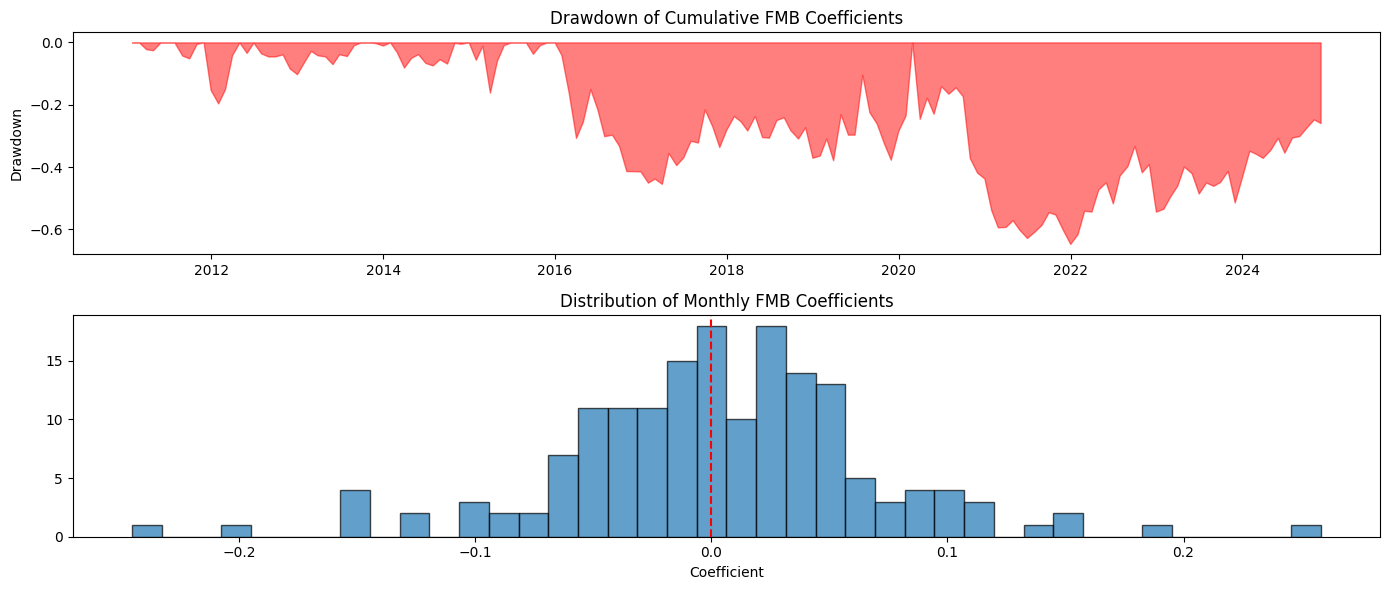

In [19]:
coefs = fmb_7b['PRC_Ret_T12M1']

# The FMB coefficient time series can be interpreted as the return
# to a zero-investment long/short momentum portfolio.

hit_rate = (coefs > 0).mean()
avg_gain = coefs[coefs > 0].mean()
avg_loss = coefs[coefs < 0].mean()
slugging = abs(avg_gain / avg_loss) if avg_loss != 0 else np.inf

# Drawdown on cumulative coefficient
cum = coefs.cumsum()
running_max = cum.cummax()
drawdown = cum - running_max
max_dd = drawdown.min()
max_dd_date = drawdown.idxmin()

# Sortino ratio: mean / downside deviation, annualized
downside_dev = np.sqrt((coefs[coefs < 0]**2).mean())
sortino = (coefs.mean() * 12) / (downside_dev * np.sqrt(12)) if downside_dev > 0 else np.inf
sharpe = (coefs.mean() * 12) / (coefs.std() * np.sqrt(12))

print("=== Performance Measures (treating FMB coefficients as strategy returns) ===")
print(f"Hit Rate:              {hit_rate:.1%}")
print(f"Avg Gain (pos months): {avg_gain:.6f}")
print(f"Avg Loss (neg months): {avg_loss:.6f}")
print(f"Slugging Ratio:        {slugging:.2f}")
print(f"Max Drawdown (cum):    {max_dd:.4f} at {max_dd_date}")
print(f"Annualized Sharpe:     {sharpe:.3f}")
print(f"Annualized Sortino:    {sortino:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color='red')
axes[0].set_title('Drawdown of Cumulative FMB Coefficients'); axes[0].set_ylabel('Drawdown')
axes[1].hist(coefs, bins=40, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('Distribution of Monthly FMB Coefficients'); axes[1].set_xlabel('Coefficient')
plt.tight_layout(); plt.show()

**Commentary on performance measures:**

The FMB coefficient can be viewed as the monthly return to a zero-investment long/short momentum portfolio. In Pedersen's framework:

- **Hit rate:** A hit rate above 50% confirms that momentum has directional persistence in most months.
- **Slugging ratio:** Even if the hit rate is only modestly above 50%, a high slugging ratio means the average winning month is larger than the average losing month.
- **Max drawdown:** This is arguably the most important metric for momentum. Momentum strategies are notorious for severe drawdowns during market reversals ("momentum crashes" per Daniel & Moskowitz 2016). The max drawdown and its timing typically correspond to post-crisis recovery periods.
- **Sortino ratio:** More relevant than Sharpe for momentum because the return distribution has a fat left tail (crash risk). The Sortino ratio, which penalizes only downside volatility, gives a more honest picture of risk-adjusted performance.
- **Sharpe ratio:** A useful summary but understates the true risk of momentum due to its negatively skewed return distribution.

---
## Question 8: Extended Fama-MacBeth Regressions

### 8(a) Univariate regressions
**Dependent variable: PRC_Ret(F1M). Independent variables: each of the following individually.**

In [20]:
# PRC in the assignment context for regression = price level
df['PRC_level'] = df['price']

univar_indeps = [
    'Price_Ret_T1', 'PRC_level', 'PRC_Ret_T12', 'Prices_Ret_T12',
    'PRC_Ret_T12M1', 'Prices_Ret_T12M1', 'PRC_Ret_T12_1M',
    'Prices_Ret_T12_1M', 'SR_Prices_Ret_T12M1'
]

all_univar_res = {}
summaries_8a = []
for var in univar_indeps:
    res = fama_macbeth(df, 'PRC_Ret_F1M', [var])
    all_univar_res[var] = res
    s = fmb_summary(res, [var])
    summaries_8a.append(s[s['Variable'] != 'const'])

summary_8a = pd.concat(summaries_8a, ignore_index=True)
print("Univariate Fama-MacBeth Regressions: PRC_Ret(F1M) ~ each variable")
display(summary_8a)

Univariate Fama-MacBeth Regressions: PRC_Ret(F1M) ~ each variable


,Variable,Mean Coef,Std,SE,t-stat,N periods
0,Price_Ret_T1,0.001210,0.166750,0.012498,0.096801,178
1,PRC_level,0.000002,0.000064,0.000005,0.322176,179
2,PRC_Ret_T12,0.002322,0.068866,0.005329,0.435674,167
3,Prices_Ret_T12,0.000445,0.059942,0.004638,0.095846,167
4,PRC_Ret_T12M1,0.002614,0.066703,0.005162,0.506339,167
5,Prices_Ret_T12M1,0.000447,0.057661,0.004462,0.100289,167
6,PRC_Ret_T12_1M,0.002335,0.168692,0.013054,0.178879,167
7,Prices_Ret_T12_1M,0.000828,0.152394,0.011793,0.070250,167
8,SR_Prices_Ret_T12M1,0.000107,0.004517,0.000350,0.304821,167


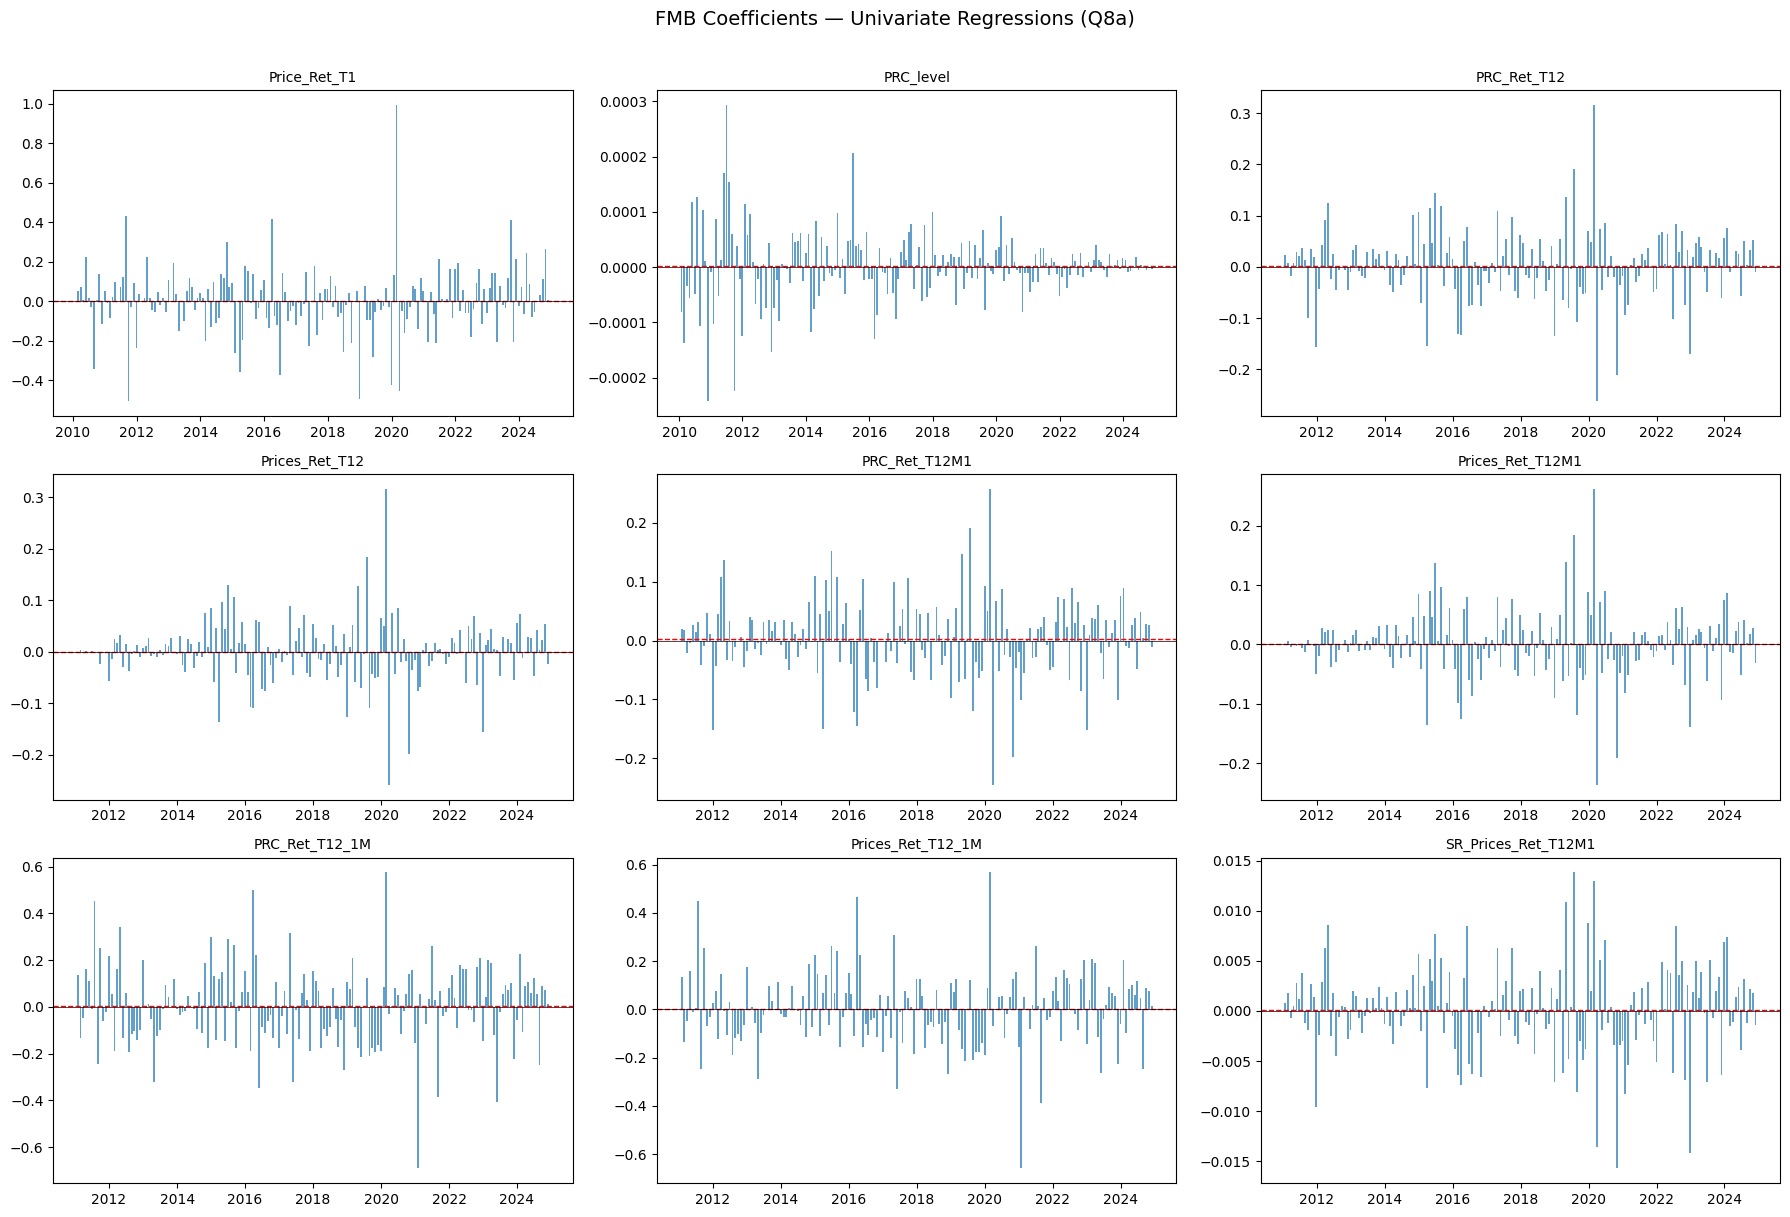

In [21]:
# Plot coefficient time series for each
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for idx, var in enumerate(univar_indeps):
    ax = axes[idx // 3][idx % 3]
    res = all_univar_res[var]
    ax.bar(res.index, res[var], width=20, alpha=0.7)
    ax.axhline(res[var].mean(), color='red', ls='--', lw=1)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(var, fontsize=10)
plt.suptitle('FMB Coefficients — Univariate Regressions (Q8a)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

**Discussion 8(a):**

We should NOT expect all variables to have the same sign:

- **Price_Ret(T1):** Expected **negative** — this is the well-known short-term reversal effect (Jegadeesh 1990). Last month's winners tend to underperform next month.
- **PRC (price level):** This is NOT a return signal. Its sign is ambiguous; it may proxy for firm size, liquidity, or institutional ownership. Low-priced stocks are often riskier.
- **PRC_Ret(T12), Prices_Ret(T12):** Full 12-month momentum. These are contaminated by the most recent month's reversal effect, making them weaker momentum signals than T12M1.
- **PRC_Ret(T12M1), Prices_Ret(T12M1):** The classic Jegadeesh-Titman momentum signal. Expected **positive**.
- **PRC_Ret(T12_1M), Prices_Ret(T12_1M):** The return from exactly 12 months ago — this captures the Heston-Sadka annual seasonality effect. Expected **positive**.
- **SR_Prices_Ret(T12M1):** Risk-adjusted momentum. Dividing by volatility may strengthen the signal for low-vol stocks or weaken it.

**Issue with PRC:** Price level is non-stationary, has extreme cross-sectional variation, and can create leverage points that distort regression coefficients. It's fundamentally different from the return-based signals.

### 8(b) Multivariate Regressions


8b-i:   Price_Ret_T1 + Prices_Ret_T12M1


,Variable,Mean Coef,Std,SE,t-stat,N periods
0,const,0.009375,0.042051,0.003254,2.881240,167
1,Price_Ret_T1,0.002579,0.172919,0.013381,0.192768,167
2,Prices_Ret_T12M1,0.002231,0.051902,0.004016,0.555390,167


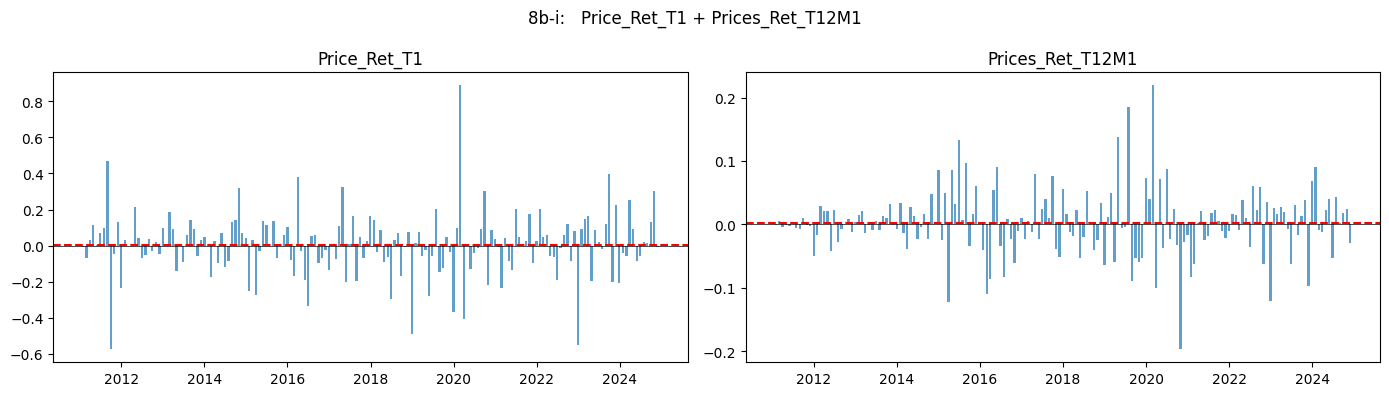


8b-ii:  PRC + PRC_Ret_T12M1


,Variable,Mean Coef,Std,SE,t-stat,N periods
0,const,0.009253,0.049342,0.003818,2.423320,167
1,PRC_level,0.000005,0.000056,0.000004,1.086703,167
2,PRC_Ret_T12M1,0.002360,0.065755,0.005088,0.463869,167


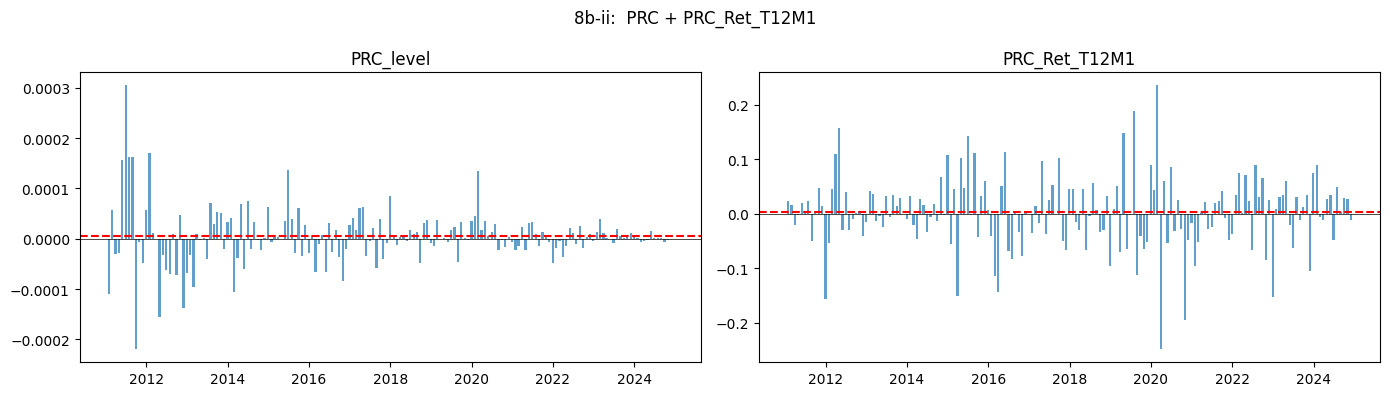


8b-iii: PRC + Prices_Ret_T12


,Variable,Mean Coef,Std,SE,t-stat,N periods
0,const,0.009221,0.046830,0.003624,2.544496,167
1,PRC_level,0.000006,0.000054,0.000004,1.427395,167
2,Prices_Ret_T12,0.000013,0.059088,0.004572,0.002933,167


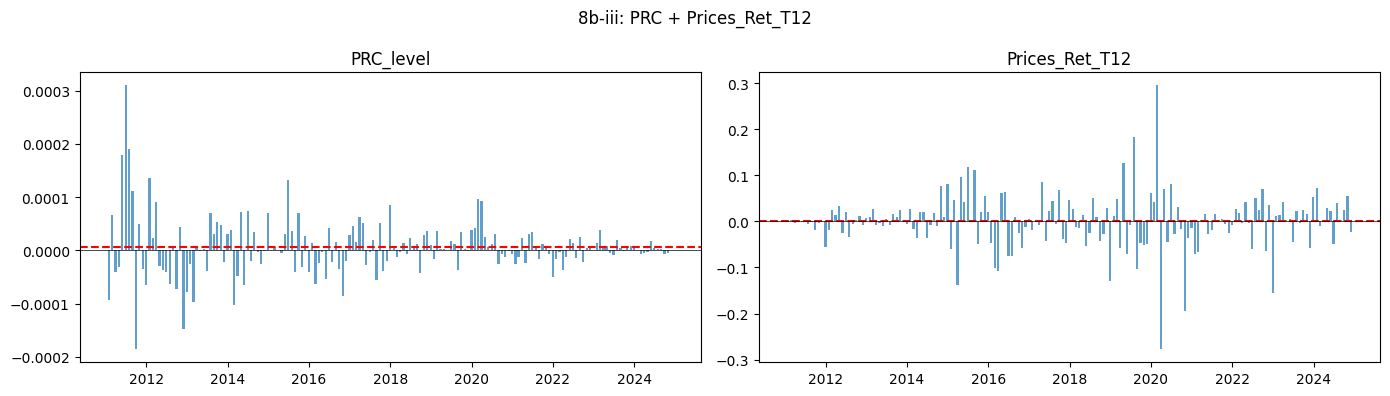


8b-iv:  PRC + SR_Prices_Ret_T12M1


,Variable,Mean Coef,Std,SE,t-stat,N periods
0,const,0.009419,0.049495,0.003830,2.459303,167
1,PRC_level,0.000005,0.000054,0.000004,1.132044,167
2,SR_Prices_Ret_T12M1,0.000093,0.004412,0.000341,0.273418,167


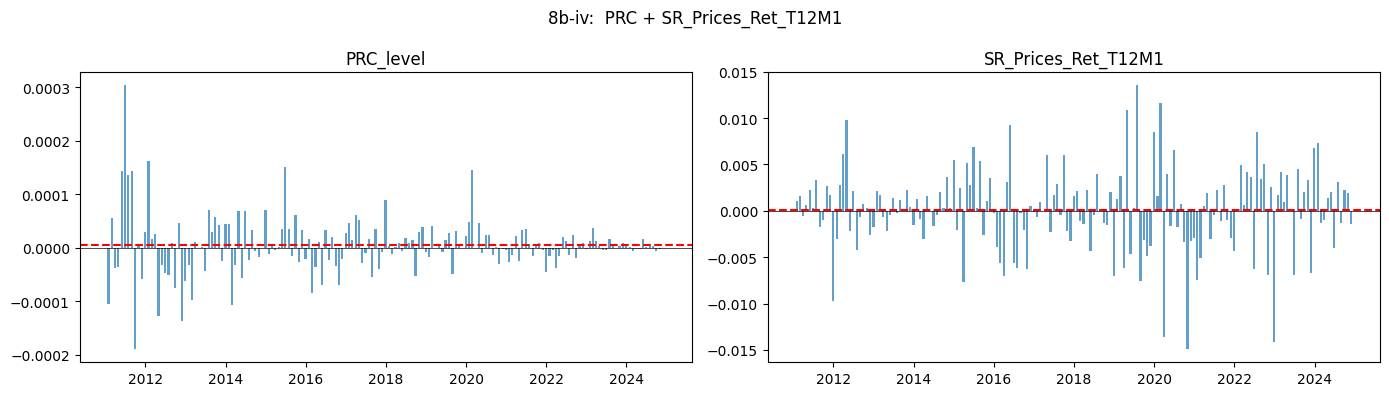

In [22]:
multivar_specs = [
    ('8b-i:   Price_Ret_T1 + Prices_Ret_T12M1',  ['Price_Ret_T1', 'Prices_Ret_T12M1']),
    ('8b-ii:  PRC + PRC_Ret_T12M1',               ['PRC_level', 'PRC_Ret_T12M1']),
    ('8b-iii: PRC + Prices_Ret_T12',               ['PRC_level', 'Prices_Ret_T12']),
    ('8b-iv:  PRC + SR_Prices_Ret_T12M1',          ['PRC_level', 'SR_Prices_Ret_T12M1']),
]

for label, vars_list in multivar_specs:
    res = fama_macbeth(df, 'PRC_Ret_F1M', vars_list)
    s = fmb_summary(res, vars_list)
    print(f"\n{'='*70}")
    print(f"{label}")
    print(f"{'='*70}")
    display(s)
    
    fig, axes = plt.subplots(1, len(vars_list), figsize=(7*len(vars_list), 4))
    if len(vars_list) == 1: axes = [axes]
    for i, v in enumerate(vars_list):
        axes[i].bar(res.index, res[v], width=20, alpha=0.7)
        axes[i].axhline(res[v].mean(), color='red', ls='--')
        axes[i].axhline(0, color='black', lw=0.5)
        axes[i].set_title(f'{v}')
    plt.suptitle(label)
    plt.tight_layout(); plt.show()

**Discussion 8(b):**

- **8b-i (Price_Ret_T1 + Prices_Ret_T12M1):** Separates short-term reversal (T1) from intermediate-term momentum (T12M1). Both effects should survive — negative for T1 (reversal) and positive for T12M1 (momentum) — confirming they are distinct phenomena.
- **8b-ii (PRC + PRC_Ret_T12M1):** Controls for price level alongside momentum. If low-priced stocks drive momentum profits, the momentum coefficient should weaken. This tests whether momentum is a "penny stock" artifact.
- **8b-iii (PRC + Prices_Ret_T12):** Full 12-month momentum (which includes the reversal month) with price control. Expect a weaker momentum coefficient than T12M1.
- **8b-iv (PRC + SR_Prices_Ret_T12M1):** Risk-adjusted momentum with price level control. Tests whether volatility normalization improves the momentum signal.

**Potential issues with PRC regressions:** Price level is non-stationary and not a return measure. It creates extreme leverage points (stocks range from single digits to thousands). It may act as an imperfect proxy for size or liquidity, introducing omitted-variable-bias-like distortions.

---
## Question 9
**Repeat 7(b) but now using the dependent variables: PRC_Ret(F3M) and PRC_Ret(F6M). Compare and contrast with 7(b). Do you see any econometric/statistical issue? Elaborate. How might you correct them?**


=== Forward 1M (Q7b): PRC_Ret_F1M ~ PRC_Ret(T12M1) ===


,Variable,Mean Coef,Std,SE,t-stat,N periods
0,const,0.009689,0.048206,0.003730,2.597362,167
1,PRC_Ret_T12M1,0.002614,0.066703,0.005162,0.506339,167


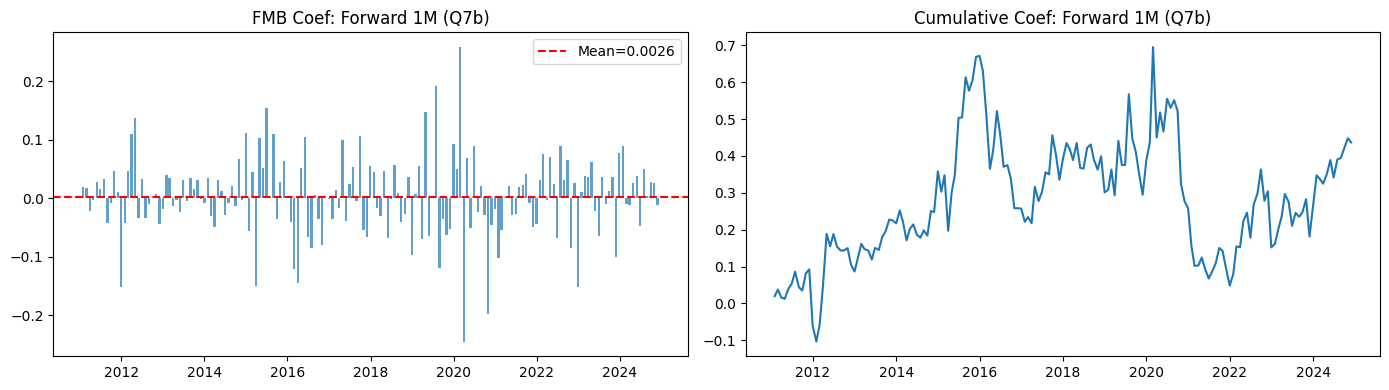


=== Forward 3M: PRC_Ret_F3M ~ PRC_Ret(T12M1) ===


,Variable,Mean Coef,Std,SE,t-stat,N periods
0,const,0.029338,0.073818,0.005747,5.105254,165
1,PRC_Ret_T12M1,0.005679,0.103886,0.008088,0.702179,165


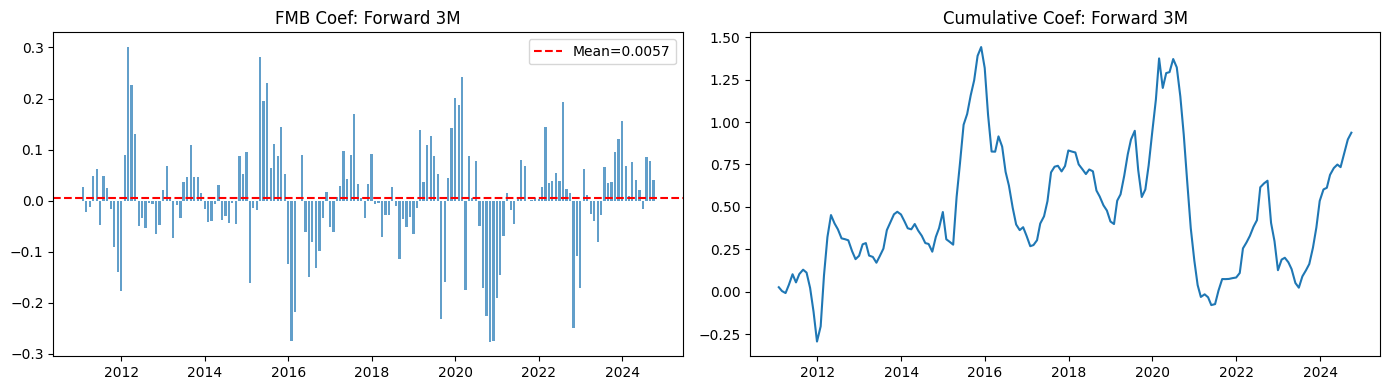


=== Forward 6M: PRC_Ret_F6M ~ PRC_Ret(T12M1) ===


,Variable,Mean Coef,Std,SE,t-stat,N periods
0,const,0.058621,0.099602,0.007825,7.490993,162
1,PRC_Ret_T12M1,0.010612,0.153600,0.012068,0.879366,162


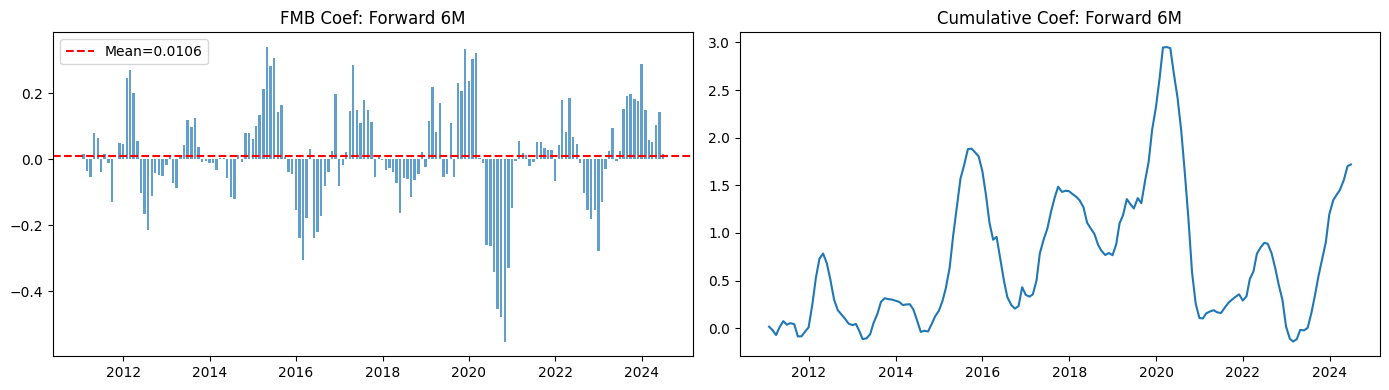

In [23]:
for dep_var, label in [('PRC_Ret_F1M','Forward 1M (Q7b)'), 
                        ('PRC_Ret_F3M','Forward 3M'), 
                        ('PRC_Ret_F6M','Forward 6M')]:
    res = fama_macbeth(df, dep_var, ['PRC_Ret_T12M1'])
    s = fmb_summary(res, ['PRC_Ret_T12M1'])
    print(f"\n=== {label}: {dep_var} ~ PRC_Ret(T12M1) ===")
    display(s)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(res.index, res['PRC_Ret_T12M1'], width=20, alpha=0.7)
    axes[0].axhline(res['PRC_Ret_T12M1'].mean(), color='red', ls='--',
                     label=f"Mean={res['PRC_Ret_T12M1'].mean():.4f}")
    axes[0].set_title(f'FMB Coef: {label}'); axes[0].legend()
    axes[1].plot(res['PRC_Ret_T12M1'].cumsum())
    axes[1].set_title(f'Cumulative Coef: {label}')
    plt.tight_layout(); plt.show()

In [24]:
# Newey-West corrected t-statistics to account for overlapping returns
print("Simple vs Newey-West adjusted t-statistics:")
print(f"{'Dep Var':<15s} {'Simple t':>10s} {'NW t':>10s} {'NW lags':>8s} {'Autocorr(1)':>12s}")
print('-'*55)

for dep_var, nlags in [('PRC_Ret_F1M', 0), ('PRC_Ret_F3M', 2), ('PRC_Ret_F6M', 5)]:
    res = fama_macbeth(df, dep_var, ['PRC_Ret_T12M1'])
    c = res['PRC_Ret_T12M1'].dropna().values
    T = len(c)
    m = c.mean()
    simple_t = m / (c.std(ddof=1) / np.sqrt(T))
    
    # Newey-West variance
    gamma0 = np.var(c, ddof=1)
    nw_var = gamma0
    for j in range(1, nlags + 1):
        w = 1 - j / (nlags + 1)  # Bartlett kernel
        gamma_j = np.mean((c[j:] - m) * (c[:-j] - m))
        nw_var += 2 * w * gamma_j
    nw_se = np.sqrt(nw_var / T)
    nw_t = m / nw_se if nw_se > 0 else np.nan
    
    # First-order autocorrelation
    ac1 = np.corrcoef(c[1:], c[:-1])[0, 1]
    
    print(f"{dep_var:<15s} {simple_t:>10.3f} {nw_t:>10.3f} {nlags:>8d} {ac1:>12.3f}")

Simple vs Newey-West adjusted t-statistics:
Dep Var           Simple t       NW t  NW lags  Autocorr(1)
-------------------------------------------------------
PRC_Ret_F1M          0.506      0.506        0       -0.154
PRC_Ret_F3M          0.702      0.505        2        0.561
PRC_Ret_F6M          0.879      0.453        5        0.795


**Comparison with 7(b):** The coefficients for longer horizons (F3M, F6M) are larger in magnitude because they compound multiple months of returns. However, the simple t-statistics can be misleading.

**Econometric issue — overlapping observations:** When using F3M or F6M as the dependent variable in monthly cross-sectional regressions, the dependent variable for adjacent months overlaps. For example, the 3-month forward return from January shares 2 months with the 3-month forward return from February. This creates **serial correlation** in the Fama-MacBeth coefficient estimates, biasing standard errors **downward** and thus inflating t-statistics (making the results appear more significant than they are).

**Corrections:**
1. **Newey-West standard errors** on the time-series of FMB coefficients with lags = horizon - 1 (e.g., lag 2 for F3M, lag 5 for F6M). The table above shows the reduction in t-statistics after correction.
2. **Non-overlapping periods only** — run regressions every 3 or 6 months instead of monthly.
3. The autocorrelation in the coefficient series confirms the overlap effect — it should be near zero for F1M but significant for F3M and F6M.

---
## Question 10
**Repeat the regressions in 7(b) where the weight on each observation is log(market cap). Compare and contrast with the original. Why this weighting function?**

In [25]:
df['log_mcap'] = np.log(df['mcap'].clip(lower=1))

fmb_wt = fama_macbeth(df, 'PRC_Ret_F1M', ['PRC_Ret_T12M1'], weight_col='log_mcap')

# Comparison table
c_uw = fmb_7b['PRC_Ret_T12M1'].dropna()
c_wt = fmb_wt['PRC_Ret_T12M1'].dropna()

comp = pd.DataFrame({
    'Metric': ['Mean Coef', 'Std', 't-stat', 'Hit Rate', 'N periods'],
    'Unweighted': [
        f"{c_uw.mean():.6f}", f"{c_uw.std():.6f}",
        f"{c_uw.mean()/(c_uw.std()/np.sqrt(len(c_uw))):.3f}",
        f"{(c_uw>0).mean()*100:.1f}%", f"{len(c_uw)}"
    ],
    'Weighted (log mcap)': [
        f"{c_wt.mean():.6f}", f"{c_wt.std():.6f}",
        f"{c_wt.mean()/(c_wt.std()/np.sqrt(len(c_wt))):.3f}",
        f"{(c_wt>0).mean()*100:.1f}%", f"{len(c_wt)}"
    ]
})
print("Comparison: Weighted vs Unweighted FMB")
display(comp)

Comparison: Weighted vs Unweighted FMB


,Metric,Unweighted,Weighted (log mcap)
0,Mean Coef,0.002614,0.002793
1,Std,0.066703,0.065671
2,t-stat,0.506,0.550
3,Hit Rate,52.1%,51.5%
4,N periods,167,167


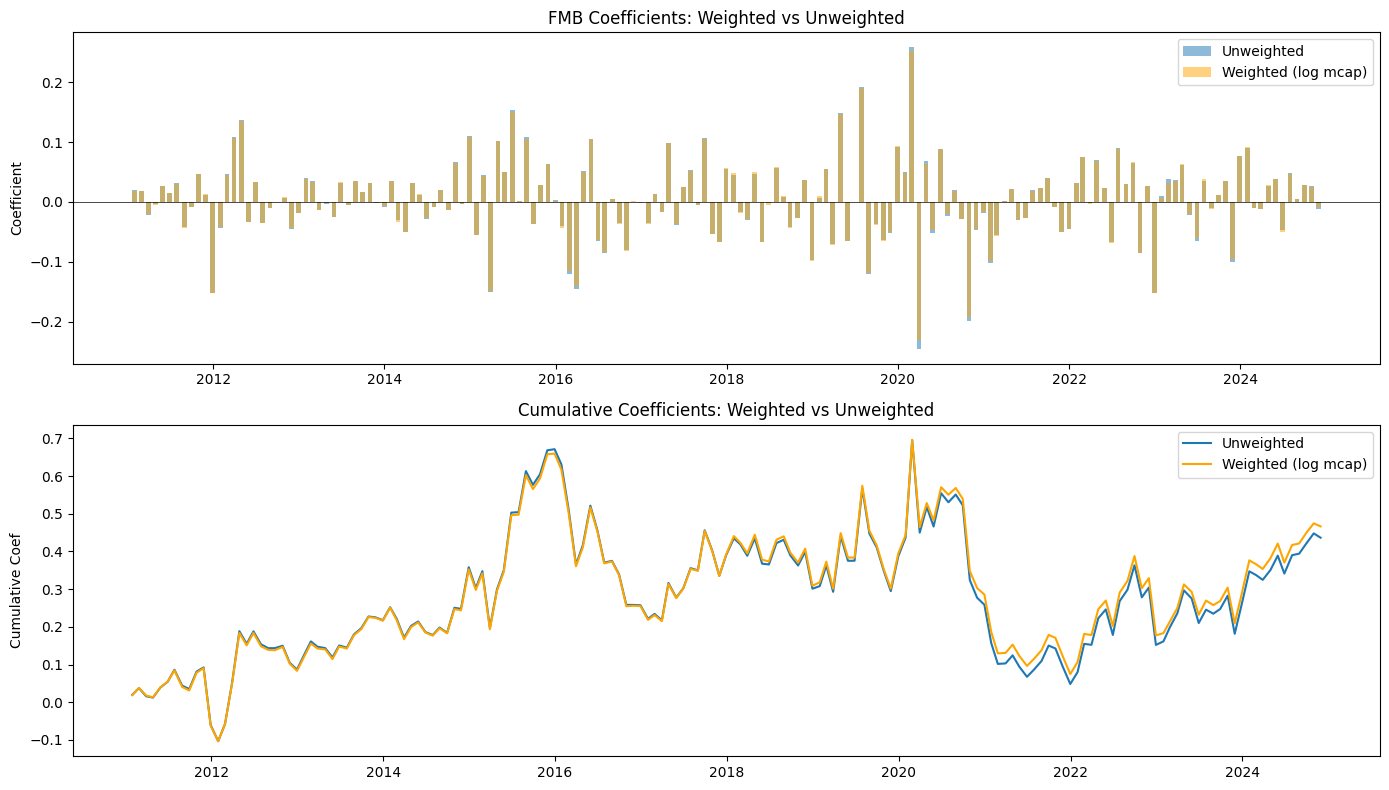

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(fmb_7b.index, fmb_7b['PRC_Ret_T12M1'], width=20, alpha=0.5, label='Unweighted')
axes[0].bar(fmb_wt.index, fmb_wt['PRC_Ret_T12M1'], width=20, alpha=0.5, label='Weighted (log mcap)', color='orange')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('FMB Coefficients: Weighted vs Unweighted')
axes[0].set_ylabel('Coefficient'); axes[0].legend()

axes[1].plot(fmb_7b['PRC_Ret_T12M1'].cumsum(), label='Unweighted')
axes[1].plot(fmb_wt['PRC_Ret_T12M1'].cumsum(), label='Weighted (log mcap)', color='orange')
axes[1].set_title('Cumulative Coefficients: Weighted vs Unweighted')
axes[1].set_ylabel('Cumulative Coef'); axes[1].legend()
plt.tight_layout(); plt.show()

**Discussion:**

**Why log(market cap) weights?** The professor asked for this specific weighting to probe several concerns:

1. **Small-stock bias:** In equal-weighted regressions, every stock has equal influence. Since there are more small-cap stocks in the S&P 500, and small caps are more volatile and have wider bid-ask spreads, they dominate the regression results. Small caps also tend to show stronger momentum effects, partly for spurious reasons (stale prices, bid-ask bounce creating artificial autocorrelation).

2. **Implementability:** An investment strategy that only works for tiny, illiquid stocks is not practically useful. By weighting by log(mcap), we test whether momentum exists among the larger, more tradeable stocks.

3. **Why log, not raw mcap?** Raw market cap would give near-100% weight to the handful of mega-cap stocks (Apple, Microsoft, etc.), making the regression reflect only those few companies. Log(mcap) compresses the scale — it gives more influence to larger stocks while still incorporating information from smaller ones. It's a middle ground between equal-weighting and value-weighting.

4. **Data quality:** Small-cap stocks are more susceptible to data issues (missing data, extreme returns from illiquidity). Downweighting them produces more reliable estimates.

If the momentum effect weakens substantially with log(mcap) weighting, it suggests the effect is concentrated in small, hard-to-trade stocks and may not be implementable as a real strategy.

---
## Question 11
**Please take a step back from the details. Explain from first principles why I might be having you do this homework. What might this have taught you about various investment strategies?**

This homework is designed to teach several fundamental lessons about quantitative investing and empirical asset pricing research:

**1. Data integrity is paramount.** Understanding total returns vs. price returns, why PERMNOs are used instead of tickers, and why the S&P 500 doesn't always have 500 stocks are all critical details. Getting any of these wrong would produce completely incorrect results, and nobody would ever point out the error — it would just silently corrupt all downstream analysis.

**2. Signal construction and decomposition matter enormously.** We constructed many versions of "momentum," and each tells a different story:
- **T12M1 vs. T12:** Skipping the most recent month matters because the last month carries a short-term reversal effect that *offsets* the intermediate-term momentum effect. Combining both in T12 produces a weaker signal.
- **Price-based vs. total-return-based:** Dividends systematically affect certain stocks (value/income stocks pay more dividends), so the choice matters.
- **Volatility-adjusted (SR):** Dividing by volatility tests whether raw returns or risk-adjusted returns are more predictive — this has implications for portfolio construction.
- **T12_1M (12-months-ago return):** This captures annual seasonality (Heston & Sadka 2008), which is a *different* anomaly from momentum. Understanding that the same data can contain multiple signals is crucial.

**3. The Fama-MacBeth methodology is foundational.** Running cross-sectional regressions each period and then analyzing the time series of coefficients is the standard approach in empirical asset pricing for testing whether a signal has persistent predictive power. It accounts for cross-sectional correlation that would bias standard panel regressions.

**4. Robustness testing is essential.** By varying the dependent variable (F1M vs. F3M vs. F6M), the weighting scheme (equal vs. log-mcap), and running both univariate and multivariate specifications, we learn whether a result is robust or fragile. A signal that only works in one specification is likely spurious or an artifact of the data.

**5. Econometric pitfalls are everywhere.** Overlapping returns bias standard errors downward. Small-cap dominance can make untradeable strategies look profitable. Including non-stationary variables (price levels) creates interpretation challenges. These are real-world issues that separate naive backtesting from rigorous research.

**6. Economic vs. statistical significance.** A signal can be statistically significant but economically unimplementable (due to transaction costs, market impact, and capacity constraints). The performance metrics (hit rate, max drawdown, Sortino ratio) help bridge this gap by translating statistical results into practical investment terms.

**7. The multivariate regressions teach about controlling for confounding factors.** When we put Price_Ret_T1 alongside T12M1, we decompose total predictability into short-term reversal and intermediate-term momentum. When we add price level, we test whether the effect is a small-stock phenomenon. This is the core skill of quantitative research: isolating the independent contribution of each signal.

**Bottom line as a quantitative researcher:** Never take a signal at face value. Decompose it to understand its sources. Stress-test it across horizons, weighting schemes, and specifications. Be aware of econometric pitfalls. And always ask: "Can I actually trade this?" The gap between a backtested anomaly and an implementable strategy is where most of the value (and most of the difficulty) lies.